# Billionaires Dataset — Applied Statistics Project Notebook

This notebook is the *single source of truth* for all analysis code and all figure/table artifacts referenced in the report.

- **Raw data (single source of truth):** `./data/raw/Billionaires Statistics Dataset.csv`
- **Outputs:** `./output/fig/` and `./output/tab/`
- **Rule:** every module produces ≥1 figure/table + takeaways, with reproducibility metadata.


## Chapter 0 — Project Contract & Research Questions (M0)

**Goal of M0:** freeze the analysis contract (RQs, roles, reproducibility) so later statistical claims are auditable and comparable.


In [66]:
# =========================
# 0.0 Imports & plotting style
# =========================
# Notes:
# - We intentionally standardize the plotting style at the start so every figure
#   has consistent typography, spacing, and (optionally) a project palette.
# - Figures are saved to disk *and* shown inline for notebook readability.

from __future__ import annotations

from pathlib import Path
from datetime import datetime
import hashlib
import json
import re
import os
import platform
import sys
from typing import Dict, List, Optional

import numpy as np
import pandas as pd

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.multitest import multipletests

import matplotlib as mpl
import matplotlib.pyplot as plt
from cycler import cycler

import seaborn as sns
from IPython.display import display

# Base style (palette will be configured after we locate the project root)
plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

In [67]:
# =======================================
# 0.1 Project paths + output helpers
# =======================================
# We want the notebook to run from (almost) anywhere inside the project folder.
# This function searches upward for project marker files, then defines all paths
# used by the notebook in ONE place.

def find_project_root(start: Optional[Path] = None) -> Path:
    if start is None:
        start = Path.cwd()
    start = start.resolve()

    markers = [
        Path("data/raw/Billionaires Statistics Dataset.csv"),
        Path("project_report.tex"),
        Path("delivery_requirments_and_standard/official_requirement.md"),
    ]

    for p in [start] + list(start.parents):
        if any((p / m).exists() for m in markers):
            return p

    # Fallback (sandbox / shared environment)
    fallback = Path("/mnt/data")
    if (fallback / "Billionaires Statistics Dataset.csv").exists():
        return fallback

    raise FileNotFoundError("Could not locate project root. Run the notebook from inside the project folder.")

ROOT = find_project_root()

DATA_RAW = ROOT / "data" / "raw" / "Billionaires Statistics Dataset.csv"
OUTPUT_FIG = ROOT / "output" / "fig"
OUTPUT_TAB = ROOT / "output" / "tab"
OUTPUT_FIG.mkdir(parents=True, exist_ok=True)
OUTPUT_TAB.mkdir(parents=True, exist_ok=True)

# Artifact registry (for report map)
ARTIFACTS: List[Dict[str, str]] = []

def file_hash(path: Path, algo: str = "sha256", chunk_size: int = 1 << 20) -> str:
    h = hashlib.new(algo)
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def load_project_palette(root: Path) -> List[str]:
    """Load a user-defined palette from ./code/color_setting.json when available."""
    candidates = [
        root / "code" / "color_setting.json",
        root / "color_setting.json",
        Path("/mnt/data/color_setting.json"),
    ]
    for p in candidates:
        if p.exists():
            obj = json.loads(p.read_text(encoding="utf-8"))
            return [c["hex"] for c in obj.get("colors", []) if "hex" in c]
    # Fallback: seaborn colorblind palette
    return sns.color_palette("colorblind").as_hex()

def reorder_palette(palette_hex: List[str]) -> List[str]:
    """Reorder user palette so the default colors start with darker blues (better for scientific plots).
    Keeps the same palette, only changes the order."""
    if len(palette_hex) >= 10:
        # For the provided blue↔rose palette, move blues/purples to the front.
        order = [6, 7, 5, 4, 3, 2, 1, 0, 9, 8]
        return [palette_hex[i] for i in order]
    return palette_hex

PALETTE = reorder_palette(load_project_palette(ROOT))


# Named colors (consistent semantics)
COLOR = {
    "primary": PALETTE[0],      # deep blue
    "secondary": PALETTE[1],    # steel blue
    "tertiary": PALETTE[2],     # grape/purple
    "accent": PALETTE[4] if len(PALETTE) > 4 else PALETTE[0],
    "highlight": PALETTE[5] if len(PALETTE) > 5 else PALETTE[0],
}

# Colormaps (for heatmaps)
CMAP_PRIMARY = sns.light_palette(COLOR["primary"], as_cmap=True)

# Apply palette globally (matplotlib + seaborn)
mpl.rcParams["axes.prop_cycle"] = cycler(color=PALETTE)
sns.set_theme(style="whitegrid", palette=PALETTE)


# -------------------------------
# Plot color helper (avoid "all pink")
# -------------------------------
# Many single-series plots default to the *first* palette color.
# We rotate a base color per-figure to improve visual variety while keeping a consistent palette.

_PLOT_COLOR_CURSOR = 0

def next_color() -> str:
    global _PLOT_COLOR_CURSOR
    c = PALETTE[_PLOT_COLOR_CURSOR % len(PALETTE)]
    _PLOT_COLOR_CURSOR += 1
    return c

def color_list(n: int) -> List[str]:
    return [next_color() for _ in range(n)]

def _ensure_parent_dir(path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)


def _log_artifact(kind: str, name: str, paths: Dict[str, str]) -> None:
    # Infer module from name prefix like fig_M6_... or tab_M7_...
    m = re.match(r"^(fig|tab)_(M\d+)_", name)
    module = m.group(2) if m else "TBD"
    ARTIFACTS.append({
        "kind": kind,
        "module": module,
        "name": name,
        "paths": json.dumps(paths),
    })

def save_table(df: pd.DataFrame, name: str, index: bool = False) -> Dict[str, str]:
    """Save a table to CSV + LaTeX and show a preview inline."""
    csv_path = OUTPUT_TAB / f"{name}.csv"
    tex_path = OUTPUT_TAB / f"{name}.tex"
    _ensure_parent_dir(csv_path)

    df.to_csv(csv_path, index=index)
    # LaTeX export: keep it simple and stable for report inclusion
    df.to_latex(tex_path, index=index, escape=True, longtable=False)

    display(df.head(20))
    paths = {"csv": str(csv_path), "tex": str(tex_path)}
    _log_artifact("table", name, paths)
    return paths

def save_fig(fig: mpl.figure.Figure, name: str) -> Dict[str, str]:
    """Save a figure to PDF + PNG and show inline."""
    pdf_path = OUTPUT_FIG / f"{name}.pdf"
    png_path = OUTPUT_FIG / f"{name}.png"
    _ensure_parent_dir(pdf_path)

    fig.tight_layout()
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    plt.show()
    paths = {"pdf": str(pdf_path), "png": str(png_path)}
    _log_artifact("figure", name, paths)
    return paths

# Project paths (display as a compact table for readability)
paths_df = pd.DataFrame([
    {"item": "ROOT", "path": str(ROOT), "exists": True},
    {"item": "DATA_RAW", "path": str(DATA_RAW), "exists": DATA_RAW.exists()},
    {"item": "OUTPUT_FIG", "path": str(OUTPUT_FIG), "exists": OUTPUT_FIG.exists()},
    {"item": "OUTPUT_TAB", "path": str(OUTPUT_TAB), "exists": OUTPUT_TAB.exists()},
    {"item": "PALETTE (hex)", "path": ", ".join(PALETTE[:6]) + (" ..." if len(PALETTE) > 6 else ""), "exists": True},
])
display(paths_df)


,item,path,exists
0,ROOT,E:\canfiles\Common courses study\大学通识\25-26 Sp...,True
1,DATA_RAW,E:\canfiles\Common courses study\大学通识\25-26 Sp...,True
2,OUTPUT_FIG,E:\canfiles\Common courses study\大学通识\25-26 Sp...,True
3,OUTPUT_TAB,E:\canfiles\Common courses study\大学通识\25-26 Sp...,True
4,PALETTE (hex),"#336BAC, #2882C1, #67619B, #8E9FD5, #B27EAE, #...",True


In [68]:
# =======================================
# 0.2 Environment snapshot (reproducibility)
# =======================================
env = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": mpl.__version__,
    "seaborn": sns.__version__,
}
env_df = pd.DataFrame([env])
save_table(env_df, "tab_M0_environment_snapshot", index=False)


,timestamp,python,platform,numpy,pandas,matplotlib,seaborn
0,2026-02-28T02:13:50,3.13.5,Windows-11-10.0.26100-SP0,2.1.3,2.2.3,3.10.0,0.13.2


{'csv': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M0_environment_snapshot.csv',
 'tex': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M0_environment_snapshot.tex'}

In [69]:
# =======================================
# 0.3 Load raw data (single source of truth) + Schema Freeze A
# =======================================
# We never modify the raw dataframe in-place. All cleaning/feature engineering is done in df_clean later.

NA_TOKENS = ["", "N/A", "None", "?", "NA", "nan"]

raw_path = DATA_RAW if DATA_RAW.exists() else (ROOT / "Billionaires Statistics Dataset.csv")
if not raw_path.exists():
    raise FileNotFoundError(f"Raw CSV not found: {raw_path}")

df_raw = pd.read_csv(raw_path, encoding="utf-8", na_values=NA_TOKENS)

display(df_raw.head(5))
display(pd.DataFrame([{"rows": df_raw.shape[0], "cols": df_raw.shape[1]}]))

freeze = {
    "freeze_id": "A",
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "raw_path": str(raw_path),
    "rows": int(df_raw.shape[0]),
    "cols": int(df_raw.shape[1]),
    "columns": list(df_raw.columns),
    "na_tokens": NA_TOKENS,
    "sha256": file_hash(raw_path, "sha256"),
    "md5": file_hash(raw_path, "md5"),
}
freeze_path = OUTPUT_TAB / "schema_freeze_A.json"
freeze_path.write_text(json.dumps(freeze, indent=2), encoding="utf-8")

freeze_summary = pd.DataFrame([freeze])[["freeze_id", "timestamp", "rows", "cols", "sha256", "md5"]]
save_table(freeze_summary, "tab_M0_schema_freeze_A_summary", index=False)


,rank,finalWorth,category,personName,age,country,city,source,industries,countryOfCitizenship,...,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,latitude_country,longitude_country
0,1,211000,Fashion & Retail,Bernard Arnault & family,74.0,France,Paris,LVMH,Fashion & Retail,France,...,1.1,"$2,715,518,274,227",65.6,102.5,82.5,24.2,60.7,67059887.0,46.227638,2.213749
1,2,180000,Automotive,Elon Musk,51.0,United States,Austin,"Tesla, SpaceX",Automotive,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
2,3,114000,Technology,Jeff Bezos,59.0,United States,Medina,Amazon,Technology,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
3,4,107000,Technology,Larry Ellison,78.0,United States,Lanai,Oracle,Technology,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
4,5,106000,Finance & Investments,Warren Buffett,92.0,United States,Omaha,Berkshire Hathaway,Finance & Investments,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891


,rows,cols
0,2640,35


,freeze_id,timestamp,rows,cols,sha256,md5
0,A,2026-02-28T02:13:50,2640,35,af398e929329cc44166e04ab763243de50d0bf049974a0...,af5e42a6886edca9e0f83330e49ad294


{'csv': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M0_schema_freeze_A_summary.csv',
 'tex': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M0_schema_freeze_A_summary.tex'}

### M0 — Research Questions (frozen)

The RQs are taken from `workbook.md` (project contract) and frozen as a table for traceability.


In [101]:
# =======================================
# 0.6 RQ table (frozen from workbook.md)
# =======================================
# We attempt to parse RQs directly from workbook.md to reduce manual drift.
# If workbook.md is not available, we fall back to a hard-coded list.

def parse_rqs_from_workbook(workbook_path: Path) -> pd.DataFrame:
    """
    Parse RQ0-RQ6 from workbook.md.

    Current workbook.md uses:
        ## RQ0(...)
        **RQ0: ... ?**
    while optional RQ5/RQ6 may appear as bold lines without "##" headings.
    This parser is tolerant to Chinese punctuation and whitespace.
    """
    text = workbook_path.read_text(encoding="utf-8", errors="ignore")

    rows = []

    # (A) Primary pattern: "## RQx ..." followed by the first bold line "**RQx：...**"
    pattern_head = r"##\s*(RQ\d+)[^\n]*\n\s*\n\*\*(RQ\d+)\s*[:：]\s*([^*]+?)\*\*"
    for rq_id_head, rq_id_bold, question in re.findall(pattern_head, text, flags=re.IGNORECASE):
        rq_id = rq_id_head.strip().upper()
        rows.append({"rq_id": rq_id, "question": f"{rq_id}: {question.strip()}"})

    # (B) Secondary pattern: bold-only optional RQs (e.g., RQ5/RQ6) without headings
    pattern_bold = r"\*\*(RQ[0-9]+)\s*[::]\s*([^*]+?)\*\*"
    for rq_id, question in re.findall(pattern_bold, text, flags=re.IGNORECASE):
        rq_id = rq_id.strip().upper()
        if rq_id.startswith("RQ"):
            rows.append({"rq_id": rq_id, "question": f"{rq_id}: {question.strip()}"})

    df_out = pd.DataFrame(rows).drop_duplicates(subset=["rq_id"]).copy()

    # Keep only RQ0–RQ6 if present; preserve ordering by rq_id numeric
    if (not df_out.empty) and ("rq_id" in df_out.columns):
        df_out = df_out[df_out["rq_id"].isin([f"RQ{i}" for i in range(7)])].copy()
        df_out["rq_num"] = df_out["rq_id"].str.replace("RQ", "", regex=False).astype(int)
        df_out = df_out.sort_values("rq_num").drop(columns=["rq_num"]).reset_index(drop=True)

    return df_out

workbook_candidates = [
    ROOT / "files_for_ai" / "workbook.md",
    ROOT / "workbook.md",
    Path("/mnt/data/workbook.md"),
]
wb_path = next((p for p in workbook_candidates if p.exists()), None)

if wb_path:
    import re
    rq_df = parse_rqs_from_workbook(wb_path)
else:
    rq_df = pd.DataFrame([
        {"rq_id": "RQ0", "question": "RQ0: Data quality (missingness/outliers/duplicates) — does it systematically bias inference?"},
        {"rq_id": "RQ1", "question": "RQ1: Is finalWorth heavy-tailed, and how dominant is the top 1%?"},
        {"rq_id": "RQ2", "question": "RQ2: Do selfMade/gender/category differ in finalWorth (effect size + CI)?"},
        {"rq_id": "RQ3", "question": "RQ3: Is finalWorth correlated with macro variables (e.g., GDP), robust to log/stratification?"},
        {"rq_id": "RQ4", "question": "RQ4: Regression — finalWorth ~ gdp_country (and log/multivariate/robust SE variants)."},
        {"rq_id": "RQ5", "question": "RQ5 (optional): Quantile regression — does GDP differ by wealth quantiles?"},
        {"rq_id": "RQ6", "question": "RQ6 (optional): Permutation/bootstrap-based inference with fewer distributional assumptions."},
    ])

# Safety fallback: if parsing fails due to workbook formatting differences, use a stable default list.
if rq_df.empty or ("rq_id" not in rq_df.columns):
    rq_df = pd.DataFrame([
        {"rq_id": "RQ0", "question": "RQ0: Data quality (missingness/outliers/duplicates) — does it systematically bias inference?"},
        {"rq_id": "RQ1", "question": "RQ1: Is finalWorth heavy-tailed, and how dominant is the top 1%?"},
        {"rq_id": "RQ2", "question": "RQ2: Do selfMade/gender/category differ in finalWorth (effect size + CI)?"},
        {"rq_id": "RQ3", "question": "RQ3: Is finalWorth correlated with macro variables (e.g., GDP), robust to log/stratification?"},
        {"rq_id": "RQ4", "question": "RQ4: Regression — finalWorth ~ gdp_country (and log/multivariate/robust SE variants)."},
        {"rq_id": "RQ5", "question": "RQ5 (optional): Quantile regression — does GDP differ by wealth quantiles?"},
        {"rq_id": "RQ6", "question": "RQ6 (optional): Permutation/bootstrap-based inference with fewer distributional assumptions."},
    ])

# English RQ phrasing (final deliverable is English). We keep the workbook-derived wording as a source record.
rq_en = {
    "RQ0": "RQ0: Does data quality (missingness/outliers/duplicates) systematically bias certain countries/industries and affect inference?",
    "RQ1": "RQ1: Is finalWorth heavy-tailed, and how dominant is the top 1% for means/variance/correlation/regression?",
    "RQ2": "RQ2: Do selfMade, gender, and category differ in finalWorth? What are the effect sizes and confidence intervals?",
    "RQ3": "RQ3: Is finalWorth associated with macro variables (e.g., GDP), and is the association robust to log transforms and stratification?",
    "RQ4": "RQ4: How well does gdp_country predict finalWorth in a simple regression, and are results stable under log, multivariate controls, and robust SE?",
    "RQ5": "RQ5 (optional): Quantile regression — does the GDP association differ across wealth quantiles?",
    "RQ6": "RQ6 (optional): Permutation / bootstrap inference to reduce distributional assumptions.",
}
rq_df["question_source"] = rq_df["question"]
rq_df["question"] = rq_df["rq_id"].map(rq_en).fillna(rq_df["question_source"])

# Map each RQ to the module(s) where it is primarily addressed
rq_to_module = {
    "RQ0": "M2",
    "RQ1": "M4",
    "RQ2": "M6",
    "RQ3": "M5/M6",
    "RQ4": "M7",
    "RQ5": "M7 (extra)",
    "RQ6": "M6/M8 (extra)",
}
rq_df["primary_module"] = rq_df["rq_id"].map(rq_to_module).fillna("TBD")

save_table(rq_df[["rq_id","question","primary_module"]], "tab_M0_research_questions", index=False)
save_table(rq_df[["rq_id","question_source"]], "tab_M0_research_questions_source", index=False)


,rq_id,question,primary_module
0,RQ0,RQ0: Does data quality (missingness/outliers/d...,M2
1,RQ1,"RQ1: Is finalWorth heavy-tailed, and how domin...",M4
2,RQ2,"RQ2: Do selfMade, gender, and category differ ...",M6
3,RQ3,RQ3: Is finalWorth associated with macro varia...,M5/M6
4,RQ4,RQ4: How well does gdp_country predict finalWo...,M7


,rq_id,question_source
0,RQ0,RQ0: 数据质量（缺失/异常/重复）是否会系统性偏向某些国家/行业，从而影响推断？
1,RQ1,RQ1: `finalWorth` 的分布是否重尾？top 1% 对整体统计量（均值/方差/...
2,RQ2,RQ2: `selfMade`、`gender`、`industry/category` 与...
3,RQ3,RQ3: `finalWorth` 与国家宏观变量（如 `gdp_country` 等）是否...
4,RQ4,RQ4: 用 `gdp_country` 预测 `finalWorth` 的简单线性回归表现...


{'csv': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M0_research_questions_source.csv',
 'tex': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M0_research_questions_source.tex'}

,role,column,in_dataset
0,Y,finalWorth,True
1,X,gdp_country,True
2,G,country,True
3,G,category,True
4,G,selfMade,True
5,G,gender,True
6,C,age,True
7,C,rank,True
8,C,cpi_country,True
9,C,life_expectancy_country,True


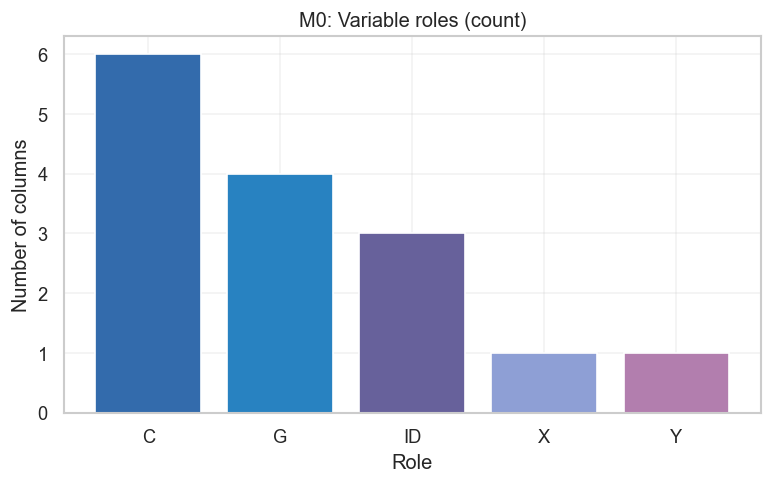

{'pdf': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M0_variable_role_counts.pdf',
 'png': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M0_variable_role_counts.png'}

In [71]:
# =======================================
# 0.4 Variable roles (explicit analysis contract)
# =======================================
# This table is a *contract*: it states which variables play what role in analysis.
# - Y: outcome(s)
# - X: key explanatory variables (required)
# - C: controls / covariates (optional, used in multivariate models)
# - G: grouping variables (used for stratification and subgroup comparisons)
# - ID: identifiers / metadata (not used as predictors unless justified)

VAR_ROLE = {
    "Y": ["finalWorth"],
    "X": ["gdp_country"],  # requirement example: finalWorth ~ gdp_country
    "G": ["country", "category", "selfMade", "gender"],
    "C": [
        "age", "rank", "cpi_country", "life_expectancy_country",
        "total_tax_rate_country", "gross_tertiary_education_enrollment",
    ],
    "ID": ["personName", "source", "industries"],
}

role_rows = []
for role, cols in VAR_ROLE.items():
    for col in cols:
        role_rows.append({
            "role": role,
            "column": col,
            "in_dataset": col in df_raw.columns
        })
roles_df = pd.DataFrame(role_rows)

save_table(roles_df, "tab_M0_variable_roles", index=False)

# Simple visualization: counts of variables by role
role_counts = roles_df.groupby("role")["column"].count().reset_index(name="n_columns")

fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.bar(role_counts["role"], role_counts["n_columns"], color=color_list(len(role_counts)))
ax.set_title("M0: Variable roles (count)")
ax.set_xlabel("Role")
ax.set_ylabel("Number of columns")
ax.grid(alpha=0.25)
save_fig(fig, "fig_M0_variable_role_counts")


In [72]:
# =======================================
# 0.5 Manual variable register (reference only)
# =======================================
# The manual register documents semantics, units, and assumptions.
# We do NOT parse it programmatically here; instead we use it as human-readable documentation.

vr_candidates = [
    ROOT / "files_for_ai" / "variable_registery.md",
    ROOT / "variable_registery.md",
    Path("/mnt/data/variable_registery.md"),
]
vr_path = next((p for p in vr_candidates if p.exists()), None)

manual_df = pd.DataFrame([{
    "manual_variable_register_path": str(vr_path) if vr_path else "NOT FOUND (optional)",
    "note": "Manual semantics live in Markdown; auto metadata is produced in M1."
}])
display(manual_df)


,manual_variable_register_path,note
0,E:\canfiles\Common courses study\大学通识\25-26 Sp...,Manual semantics live in Markdown; auto metada...


### M0 Takeaways (report-ready)

**Core takeaways**
1. A reproducible **Schema Freeze A** (hashes, NA tokens, column order) is written to `output/tab/schema_freeze_A.json`, ensuring every downstream result can be audited back to a specific raw snapshot.
2. An explicit **variable-role contract** (Y/X/G/C/ID) is frozen before any modeling; this prevents post-hoc variable selection from silently changing the analysis target.

**Exploratory / innovative takeaways**
1. The notebook enforces a dual-evidence structure: **manual semantics** (Markdown register) + **auto metadata** (tables exported in M1), reducing “documentation drift”.
2. A project palette is loaded from `./code/color_setting.json` when available to keep figure styling consistent across modules and across team members.


## Chapter 1 — Data Ingestion & Variable Register (M1)

**Goal of M1:** produce auto-generated metadata (schema, missingness rates, uniqueness) and run a small set of *data-driven dictionary checks* that lock down ambiguous column meanings.


## Chapter 1 — Data Ingestion & Variable Register (M1)
**Goal:** Load the raw dataset once, document schema/dtypes/missingness, and validate key dictionary claims.
**Note:** this module is descriptive/metadata-only; substantive DQ decisions start in M2.


,column,dtype,missing_n,missing_pct,nunique,example_or_top_levels
0,organization,object,2315,0.876894,294,Meta Platforms (4); Gap Inc. (3); Alphabet (2)
1,title,object,2301,0.871591,97,Investor (44); Founder (34); CEO (29)
2,residenceStateRegion,object,1893,0.717045,5,West (248); South (241); Northeast (190)
3,state,object,1887,0.714773,45,California (178); New York (128); Florida (94)
4,cpi_change_country,float64,184,0.069697,44,1.1
5,cpi_country,float64,184,0.069697,63,110.05
6,tax_revenue_country_country,float64,183,0.069318,57,24.2
7,life_expectancy_country,float64,182,0.068939,54,82.5
8,gross_tertiary_education_enrollment,float64,182,0.068939,63,65.6
9,total_tax_rate_country,float64,182,0.068939,63,60.7


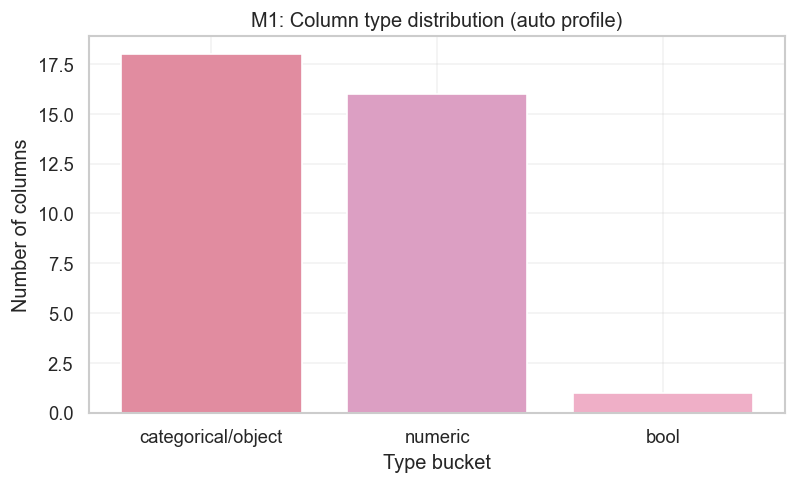

In [73]:
# =======================================
# 1.1 Auto schema summary / variable register (metadata)
# =======================================
# Purpose:
# - Provide an auto-generated, reproducible snapshot of column types, missingness,
#   and cardinality. This complements the manual register (semantics).
#
# Output artifacts:
# - tab_M1_schema_summary.{csv,tex}
# - fig_M1_dtype_distribution.{pdf,png}

def make_schema_summary(df: pd.DataFrame) -> pd.DataFrame:
    n = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        miss_n = int(s.isna().sum())
        nunique = int(s.nunique(dropna=True))
        dtype = str(s.dtype)

        # Representative example(s) for readability (avoid huge strings)
        example = ""
        if dtype == "object":
            top = s.dropna().astype(str).value_counts().head(3)
            example = "; ".join([f"{k} ({v})" for k, v in top.items()])
        else:
            example = str(s.dropna().iloc[0]) if s.dropna().shape[0] > 0 else ""

        rows.append({
            "column": col,
            "dtype": dtype,
            "missing_n": miss_n,
            "missing_pct": miss_n / n,
            "nunique": nunique,
            "example_or_top_levels": example[:120],
        })

    out = pd.DataFrame(rows)
    # Sort by missingness (desc), then cardinality (asc)
    return out.sort_values(["missing_pct", "nunique"], ascending=[False, True]).reset_index(drop=True)

tab_schema = make_schema_summary(df_raw)
save_table(tab_schema, "tab_M1_schema_summary", index=False)

# Dtype distribution (coarse categories) — a small "profile" figure for M1
def dtype_bucket(dtype_str: str) -> str:
    d = dtype_str.lower()
    if "int" in d or "float" in d:
        return "numeric"
    if "bool" in d:
        return "bool"
    if "datetime" in d:
        return "datetime"
    return "categorical/object"

dtype_counts = tab_schema["dtype"].map(dtype_bucket).value_counts().reset_index()
dtype_counts.columns = ["dtype_bucket", "n_columns"]

fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.bar(dtype_counts["dtype_bucket"], dtype_counts["n_columns"], color=color_list(len(dtype_counts)))
ax.set_title("M1: Column type distribution (auto profile)")
ax.set_xlabel("Type bucket")
ax.set_ylabel("Number of columns")
ax.grid(alpha=0.25)
save_fig(fig, "fig_M1_dtype_distribution")

# Staging dataframe for downstream modules (non-destructive)
df = df_raw.copy()


In [74]:
# =======================================
# 1.2 Minimal parsing for macro variables (non-destructive)
# =======================================
# `gdp_country` is often stored as a formatted currency string (e.g., '$1,234.56').
# To use it in correlation/regression, we create a numeric derivative.
#
# Output artifact:
# - tab_M1_gdp_parse_summary.{csv,tex}

def parse_money_like(x) -> float:
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    # Remove common formatting artifacts
    s = s.replace("$", "").replace(",", "").replace(" ", "")
    try:
        return float(s)
    except Exception:
        return np.nan

if "gdp_country" in df.columns:
    df["gdp_country_num"] = df["gdp_country"].map(parse_money_like)
    df["log_gdp"] = np.log1p(df["gdp_country_num"])
else:
    df["gdp_country_num"] = np.nan
    df["log_gdp"] = np.nan

# Heavy-tail transform for wealth (does not modify original column)
df["log_finalWorth"] = np.log1p(pd.to_numeric(df["finalWorth"], errors="coerce"))

parse_summary = pd.DataFrame([{
    "col": "gdp_country",
    "raw_nonmissing_n": int(df["gdp_country"].notna().sum()) if "gdp_country" in df.columns else 0,
    "parsed_nonmissing_n": int(df["gdp_country_num"].notna().sum()),
    "parse_success_rate_among_raw_nonmissing": float(df["gdp_country_num"].notna().sum() / max(1, (df["gdp_country"].notna().sum() if "gdp_country" in df.columns else 1))),
}])
save_table(parse_summary, "tab_M1_gdp_parse_summary", index=False)


,col,raw_nonmissing_n,parsed_nonmissing_n,parse_success_rate_among_raw_nonmissing
0,gdp_country,2476,2476,1.0


{'csv': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M1_gdp_parse_summary.csv',
 'tex': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M1_gdp_parse_summary.tex'}

In [75]:
# =======================================
# 1.3 Data-driven dictionary verification checks (evidence chain)
# =======================================
# We record key "meaning constraints" that are inferred from the data itself.
# These checks help prevent ambiguous interpretations later in the report.
#
# Output artifact:
# - tab_M1_dictionary_verification_checks.{csv,tex}

checks = []

# Check 1: category vs industries (often redundant in this dataset)
if ("category" in df.columns) and ("industries" in df.columns):
    identical = bool((df["category"].fillna("__NA__") == df["industries"].fillna("__NA__")).all())
    checks.append({
        "check": "category_equals_industries",
        "result": "PASS" if identical else "FAIL",
        "evidence": "All rows identical after NA normalization" if identical else "Some rows differ",
    })
else:
    checks.append({
        "check": "category_equals_industries",
        "result": "SKIP",
        "evidence": "One or both columns missing",
    })

# Check 2: US-only state fields (structural missingness hypothesis; formalized in M2)
if ("country" in df.columns) and ("state" in df.columns):
    non_us_with_state = int(((df["country"] != "United States") & df["state"].notna()).sum())
    checks.append({
        "check": "state_present_only_for_US",
        "result": "PASS" if non_us_with_state == 0 else "FAIL",
        "evidence": f"Non-US records with state info: {non_us_with_state}",
    })

checks_df = pd.DataFrame(checks)
save_table(checks_df, "tab_M1_dictionary_verification_checks", index=False)


,check,result,evidence
0,category_equals_industries,PASS,All rows identical after NA normalization
1,state_present_only_for_US,PASS,Non-US records with state info: 0


{'csv': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M1_dictionary_verification_checks.csv',
 'tex': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M1_dictionary_verification_checks.tex'}

### M1 Takeaways (report-ready)

**Core takeaways**
1. Auto metadata tables (schema, missingness rates, cardinality) provide a reproducible companion to the manual variable register, reducing the risk of “semantic drift”.
2. `gdp_country` is converted into a numeric derivative (`gdp_country_num`) and a log derivative (`log_gdp`) so downstream correlation/regression can be computed on a well-defined scale.

**Exploratory / innovative takeaways**
1. Data-driven checks are recorded as a table (e.g., `category == industries`), turning informal “facts” into auditable artifacts.
2. Dtype distribution profiling is exported as a figure, providing a quick sanity check of dataset structure before deeper quality auditing.


## Chapter 2 — Data Quality Audit (M2)

**Goal of M2:** quantify missingness/outliers/duplicates and identify *structural* patterns (e.g., US-only fields) that could bias inference.

### Adversarial review (what an examiner might challenge)
- “Are missing values random, or concentrated in specific countries/industries?”
- “Are your summaries dominated by a tiny number of ultra-wealthy outliers?”
- “Did parsing/cleaning silently delete information or change denominators?”

### Design response
- Report missingness overall **and** by key groups.
- Visualize the outcome on both raw and log scales.
- Keep an evidence chain: every check produces a table/figure artifact.


### Adversarial review (M2)
- *Threat:* Missingness differs by country/industry → biased comparisons.
- *Threat:* Outliers dominate mean/correlation/regression.
- *Threat:* Structural fields (state/region) are not missing at random (US-only).

**Design response:** quantify missingness overall + by group (heatmap), keep both raw/log views, and document structural missingness explicitly.


## Chapter 2 — Data Quality Audit (M2)
**Goal:** Establish a credibility baseline for all later inference/regression.
**Reviewer checklist:** (i) missingness patterns, (ii) structural missingness (e.g., US-only state), (iii) duplicates, (iv) outliers / range issues.
**Includes a heatmap:** missingness-by-country heatmap is produced in section 2.2.


,column,missing_pct,missing_n,dtype
0,organization,87.69,2315,object
1,title,87.16,2301,object
2,residenceStateRegion,71.70,1893,object
3,state,71.48,1887,object
4,cpi_change_country,6.97,184,float64
5,cpi_country,6.97,184,float64
6,tax_revenue_country_country,6.93,183,float64
7,life_expectancy_country,6.89,182,float64
8,gross_tertiary_education_enrollment,6.89,182,float64
9,total_tax_rate_country,6.89,182,float64


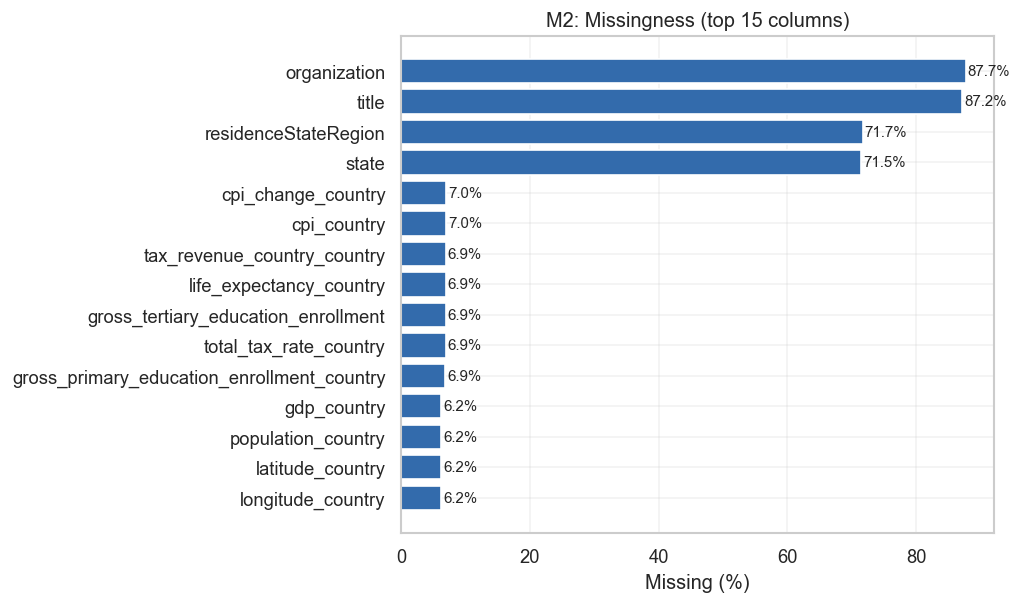

{'pdf': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M2_missingness_top15.pdf',
 'png': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M2_missingness_top15.png'}

In [76]:
# =======================================
# 2.1 Overall missingness profile (top columns)
# =======================================
# This figure/table is the baseline “data-quality footprint” used in RQ0.

schema = tab_schema.copy()  # from M1
schema["missing_pct"] = schema["missing_pct"].astype(float)

topk = 15
miss_top = schema.sort_values("missing_pct", ascending=False).head(topk)[
    ["column", "missing_pct", "missing_n", "dtype"]
].copy()
miss_top["missing_pct"] = (miss_top["missing_pct"] * 100).round(2)

save_table(miss_top, "tab_M2_missingness_top15", index=False)

fig, ax = plt.subplots(figsize=(8.6, 5.2))
ax.barh(miss_top["column"][::-1], miss_top["missing_pct"][::-1])
ax.set_title("M2: Missingness (top 15 columns)")
ax.set_xlabel("Missing (%)")
ax.set_ylabel("")
for i, v in enumerate(miss_top["missing_pct"][::-1].values):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
ax.grid(alpha=0.25)
save_fig(fig, "fig_M2_missingness_top15")


,country,age,gender,selfMade,rank,gdp_country_num,category,state,residenceStateRegion
0,Australia,0.000000,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000
1,Brazil,0.022727,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000
2,China,0.036329,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000
3,Germany,0.137255,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000
4,Hong Kong,0.029412,0.0,0.0,0.0,1.0,0.0,1.000000,1.000000
5,India,0.000000,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000
6,Italy,0.000000,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000
7,Russia,0.000000,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000
8,Singapore,0.000000,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000
9,Switzerland,0.038462,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000


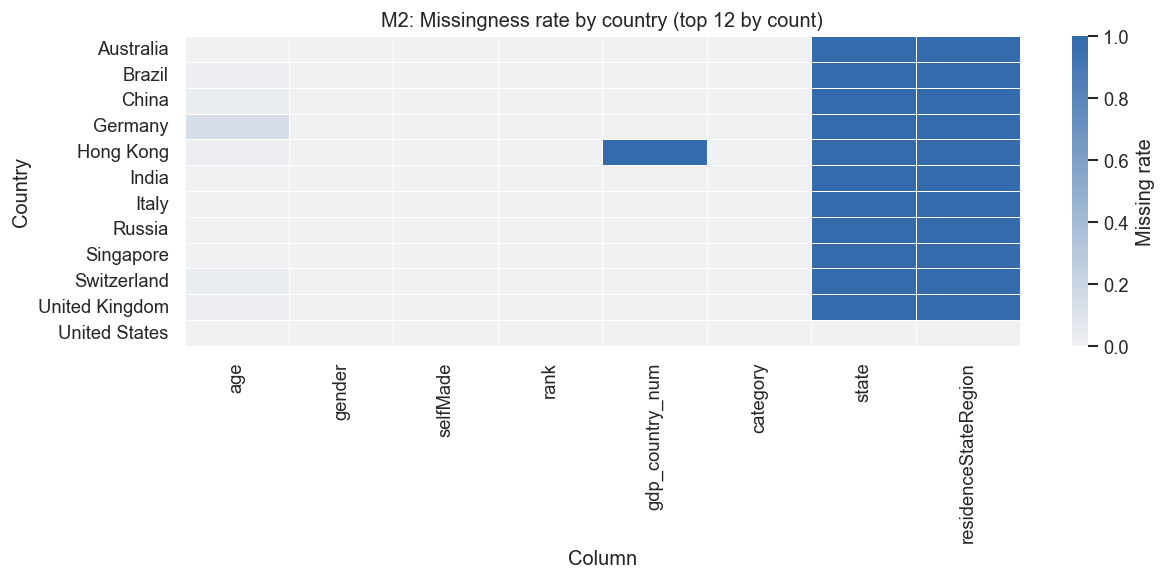

{'pdf': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M2_missingness_heatmap_country_top12.pdf',
 'png': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M2_missingness_heatmap_country_top12.png'}

In [77]:
# =======================================
# 2.2 Missingness by country (heatmap for top countries)
# =======================================
# Rationale:
# - If missingness is concentrated in certain countries, naive comparisons may be biased.

group_col = "country"
focus_cols = ["age", "gender", "selfMade", "rank", "gdp_country_num", "category", "state", "residenceStateRegion"]
focus_cols = [c for c in focus_cols if c in df.columns]

# Choose top countries by sample size
top_countries = df[group_col].value_counts(dropna=False).head(12).index.tolist()
df_top = df[df[group_col].isin(top_countries)].copy()

miss_by_country = (
    df_top.groupby(group_col)[focus_cols]
         .apply(lambda g: g.isna().mean())
         .reset_index()
)
miss_m = miss_by_country.set_index(group_col)

save_table(miss_m.reset_index(), "tab_M2_missingness_by_country_top12", index=False)

fig, ax = plt.subplots(figsize=(10.5, 5.0))
sns.heatmap(miss_m, cmap=CMAP_PRIMARY, vmin=0, vmax=1, linewidths=0.5, linecolor="white", cbar_kws={"label": "Missing rate"}, ax=ax)
ax.set_title("M2: Missingness rate by country (top 12 by count)")
ax.set_xlabel("Column")
ax.set_ylabel("Country")
save_fig(fig, "fig_M2_missingness_heatmap_country_top12")


,group,n_records,state_coverage,residenceStateRegion_coverage
0,US,754,0.998674,0.990716
1,Non-US,1886,0.000000,0.000000


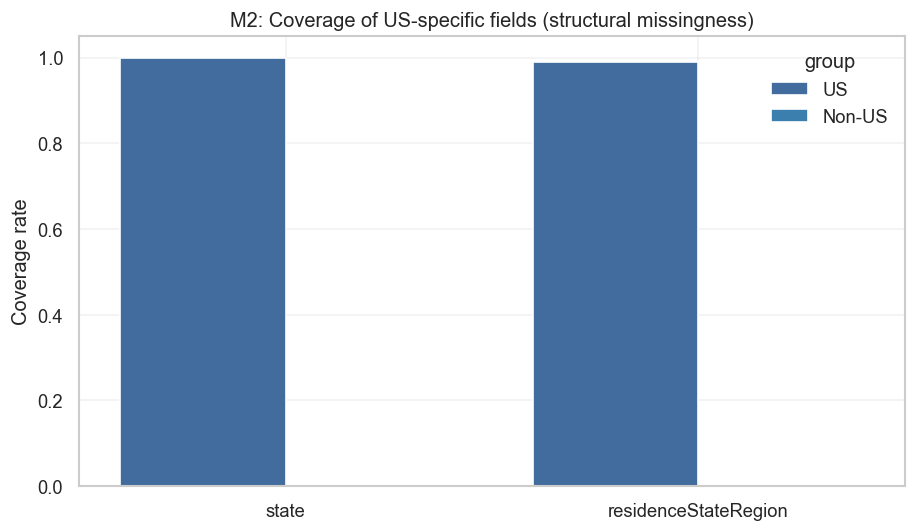

In [78]:
# =======================================
# 2.3 Structural missingness: state / residenceStateRegion (US-only hypothesis)
# =======================================
# Hypothesis: these fields are only populated for US records, so high overall missingness
# does not necessarily indicate low data quality.

if "country" in df.columns:
    is_us = (df["country"] == "United States")
else:
    is_us = pd.Series([False] * len(df))

cols = [c for c in ["state", "residenceStateRegion"] if c in df.columns]
if cols:
    cov = pd.DataFrame({
        "group": ["US", "Non-US"],
        "n_records": [int(is_us.sum()), int((~is_us).sum())],
    })
    for c in cols:
        cov[f"{c}_coverage"] = [
            float(df.loc[is_us, c].notna().mean()) if is_us.sum() > 0 else np.nan,
            float(df.loc[~is_us, c].notna().mean()) if (~is_us).sum() > 0 else np.nan,
        ]
    save_table(cov, "tab_M2_us_only_state_coverage", index=False)

    # Visualization
    fig, ax = plt.subplots(figsize=(7.8, 4.6))
    plot_df = cov.melt(id_vars=["group", "n_records"], value_vars=[f"{c}_coverage" for c in cols],
                       var_name="field", value_name="coverage")
    plot_df["field"] = plot_df["field"].str.replace("_coverage", "", regex=False)

    sns.barplot(data=plot_df, x="field", y="coverage", hue="group", ax=ax)
    ax.set_title("M2: Coverage of US-specific fields (structural missingness)")
    ax.set_xlabel("")
    ax.set_ylabel("Coverage rate")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.25)
    save_fig(fig, "fig_M2_us_only_state_coverage")
else:
    display(pd.DataFrame([{"note": "state/residenceStateRegion not present in dataset"}]))


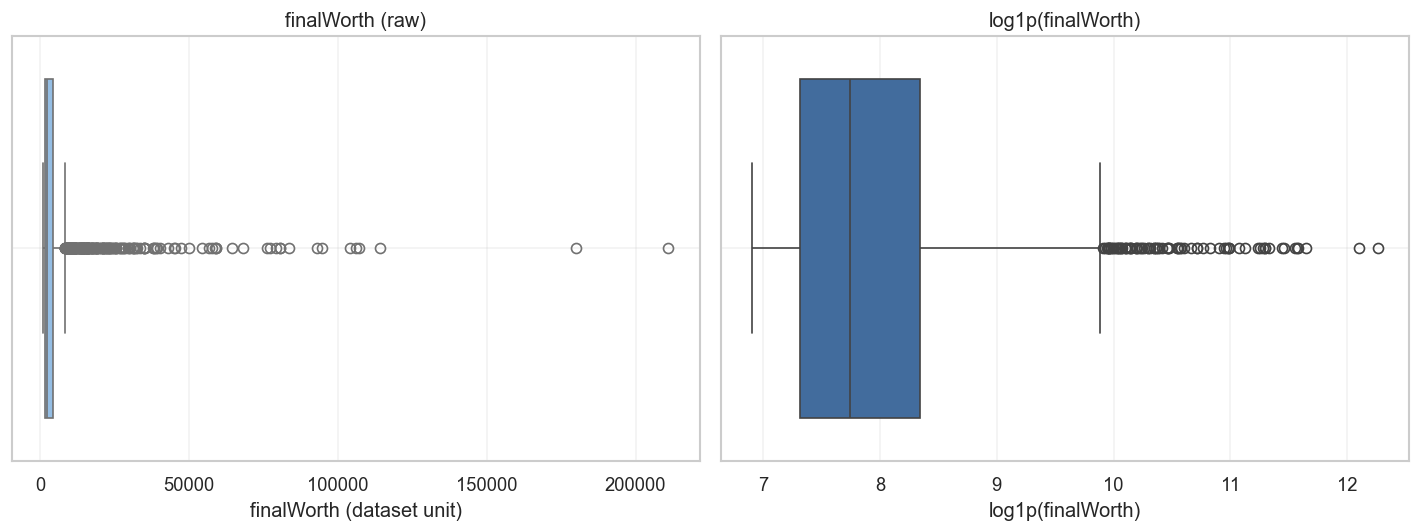

{'pdf': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M2_outliers_raw_vs_log_box.pdf',
 'png': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M2_outliers_raw_vs_log_box.png'}

In [79]:
# =======================================
# 2.4 Outliers: finalWorth on raw vs log scale
# =======================================
# Heavy-tailed outcomes can dominate means, correlations, and regression slopes.
# We visualize both scales early so downstream modeling choices are justified.

y_raw = pd.to_numeric(df["finalWorth"], errors="coerce")
y_log = df["log_finalWorth"]

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))

sns.boxplot(x=y_raw, ax=axes[0], palette=[next_color(), next_color()])
axes[0].set_title("finalWorth (raw)")
axes[0].set_xlabel("finalWorth (dataset unit)")
axes[0].grid(alpha=0.25)

sns.boxplot(x=y_log, ax=axes[1])
axes[1].set_title("log1p(finalWorth)")
axes[1].set_xlabel("log1p(finalWorth)")
axes[1].grid(alpha=0.25)

save_fig(fig, "fig_M2_outliers_raw_vs_log_box")


In [80]:
# =======================================
# 2.5 Consolidated DQ issues table (evidence chain)
# =======================================
issues = []

# Duplicate rows (exact duplicates)
n_dup_rows = int(df.duplicated().sum())
issues.append({"issue": "Exact duplicate rows", "metric": "count", "value": n_dup_rows, "note": "informational; handling decided in M3"})

# Basic range sanity checks (illustrative; adjust if project documentation provides stricter rules)
def count_outside(col: str, low: float, high: float) -> int:
    s = pd.to_numeric(df[col], errors="coerce")
    return int(((s < low) | (s > high)).sum())

if "age" in df.columns:
    issues.append({"issue": "Age outside [0, 120]", "metric": "count", "value": count_outside("age", 0, 120), "note": "sanity check"})
if "rank" in df.columns:
    issues.append({"issue": "Rank <= 0", "metric": "count", "value": int((pd.to_numeric(df["rank"], errors="coerce") <= 0).sum()), "note": "sanity check"})

# GDP parse failures (when raw non-missing but numeric is missing)
if "gdp_country" in df.columns:
    raw_nonmiss = df["gdp_country"].notna()
    parse_fail = int((raw_nonmiss & df["gdp_country_num"].isna()).sum())
    issues.append({"issue": "GDP parse failures", "metric": "count", "value": parse_fail, "note": "requires cleaning rule or exclusion in regression"})

issues_df = pd.DataFrame(issues)
save_table(issues_df, "tab_M2_dq_issues_summary", index=False)


,issue,metric,value,note
0,Exact duplicate rows,count,0,informational; handling decided in M3
1,"Age outside [0, 120]",count,0,sanity check
2,Rank <= 0,count,0,sanity check
3,GDP parse failures,count,0,requires cleaning rule or exclusion in regression


{'csv': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M2_dq_issues_summary.csv',
 'tex': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M2_dq_issues_summary.tex'}

In [81]:
# =======================================
# 2.6 Artifact index (M2 outputs)
# =======================================
artifact_index = pd.DataFrame([
    {"module": "M2", "type": "table", "name": "tab_M2_missingness_top15"},
    {"module": "M2", "type": "figure", "name": "fig_M2_missingness_top15"},
    {"module": "M2", "type": "table", "name": "tab_M2_missingness_by_country_top12"},
    {"module": "M2", "type": "figure", "name": "fig_M2_missingness_heatmap_country_top12"},
    {"module": "M2", "type": "table", "name": "tab_M2_us_only_state_coverage"},
    {"module": "M2", "type": "figure", "name": "fig_M2_us_only_state_coverage"},
    {"module": "M2", "type": "figure", "name": "fig_M2_outliers_raw_vs_log_box"},
    {"module": "M2", "type": "table", "name": "tab_M2_dq_issues_summary"},
])
save_table(artifact_index, "tab_M2_artifact_index", index=False)


,module,type,name
0,M2,table,tab_M2_missingness_top15
1,M2,figure,fig_M2_missingness_top15
2,M2,table,tab_M2_missingness_by_country_top12
3,M2,figure,fig_M2_missingness_heatmap_country_top12
4,M2,table,tab_M2_us_only_state_coverage
5,M2,figure,fig_M2_us_only_state_coverage
6,M2,figure,fig_M2_outliers_raw_vs_log_box
7,M2,table,tab_M2_dq_issues_summary


{'csv': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M2_artifact_index.csv',
 'tex': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M2_artifact_index.tex'}

### M2 Takeaways (report-ready)

**Core takeaways**
1. Missingness is **not uniform**: key variables show measurable missingness, and missingness can concentrate by country; any inference must report denominators and consider stratification or robustness checks.
2. `finalWorth` is strongly heavy-tailed; results on the raw scale risk being dominated by extreme values, so log-scale analysis is a default robustness route.

**Exploratory / innovative takeaways**
1. US-specific geographic fields (`state`, `residenceStateRegion`) exhibit *structural missingness* (coverage near 0 for non-US), which should be handled as “not applicable” rather than “bad data”.
2. A consolidated issues table (duplicates, range sanity, parse failures) creates an auditable DQ summary that can be referenced in the report without re-running ad-hoc checks.


## Chapter 3 — Cleaning & Feature Engineering (M3)

**Goal of M3:** build `df_clean` with minimal, auditable transformations (type conversions + derived columns) and log every change.

### Adversarial review
- “Did cleaning change sample size or the definition of key variables?”
- “Are you accidentally imputing or deleting data without reporting it?”

### Design response
- Keep raw data intact (`df_raw`).
- Create `df_clean` as a copy with *explicit* derived columns only.
- Export a cleaning log table and (optionally) a cleaned CSV for reproducibility.


## Chapter 3 — Minimal Cleaning (M3)
**Goal:** Create a clean analysis dataset (`df_clean`) with transparent, auditable rules.
**Key principle:** do not modify raw columns; add derived columns and log all changes.


In [82]:
# =======================================
# 3.1 Minimal cleaning pipeline (auditable, non-destructive)
# =======================================
# Principles:
# 1) Never overwrite raw columns with "guessed" semantics.
# 2) Prefer type conversions that are reversible and documented.
# 3) Add derived columns with explicit names (e.g., *_num, log_*).

df_clean = df.copy()

clean_log = []

# 1) Strip whitespace for object columns (safe normalization)
obj_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()
for col in obj_cols:
    before_na = int(df_clean[col].isna().sum())
    df_clean[col] = df_clean[col].astype(str).str.strip().replace({"nan": np.nan})
    after_na = int(df_clean[col].isna().sum())
    if after_na != before_na:
        clean_log.append({"step": "strip_whitespace", "column": col, "note": f"NA count {before_na} -> {after_na}"})

# 2) Coerce key numeric columns
for col in ["finalWorth", "age", "rank"]:
    if col in df_clean.columns:
        before_nonnum = int(pd.to_numeric(df_clean[col], errors="coerce").isna().sum())
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
        after_nonnum = int(df_clean[col].isna().sum())
        clean_log.append({"step": "to_numeric", "column": col, "note": f"NA after coercion: {after_nonnum} (was {before_nonnum} under coercion check)"})

# 3) Canonical handling for redundant columns (do NOT drop raw columns)
# Data check in M1 suggests category == industries in this dataset.
# We keep both, but treat 'category' as canonical in analysis.
if ("category" in df_clean.columns) and ("industries" in df_clean.columns):
    df_clean["category_canonical"] = df_clean["category"]
    clean_log.append({"step": "canonical_category", "column": "category_canonical", "note": "Set to category (industries retained as raw column)"})
else:
    df_clean["category_canonical"] = df_clean.get("category", np.nan)

# 4) Ensure GDP derivatives exist (already created in M1)
if "gdp_country_num" not in df_clean.columns:
    df_clean["gdp_country_num"] = np.nan
if "log_gdp" not in df_clean.columns:
    df_clean["log_gdp"] = np.log1p(df_clean["gdp_country_num"])

# 5) Ensure log outcome exists
if "log_finalWorth" not in df_clean.columns:
    df_clean["log_finalWorth"] = np.log1p(df_clean["finalWorth"])

# 6) Optional flags helpful for later stratification / robustness
if "country" in df_clean.columns:
    df_clean["is_us"] = (df_clean["country"] == "United States")
if "selfMade" in df_clean.columns:
    # keep original; add a boolean helper when selfMade is 0/1-like
    sm = pd.to_numeric(df_clean["selfMade"], errors="coerce")
    df_clean["selfMade_bool"] = sm.where(sm.isna(), sm.astype(int).astype(bool))

display(pd.DataFrame([{"rows": df_clean.shape[0], "cols": df_clean.shape[1]}]))


,rows,cols
0,2640,41


In [83]:
# =======================================
# 3.2 Cleaning log (what changed)
# =======================================
# This log is meant to be report-friendly: short, explicit, and auditable.

clean_log_df = pd.DataFrame(clean_log) if len(clean_log) else pd.DataFrame([{"step": "none", "column": "", "note": "No changes recorded"}])
save_table(clean_log_df, "tab_M3_cleaning_log", index=False)


,step,column,note
0,to_numeric,finalWorth,NA after coercion: 0 (was 0 under coercion check)
1,to_numeric,age,NA after coercion: 65 (was 65 under coercion c...
2,to_numeric,rank,NA after coercion: 0 (was 0 under coercion check)
3,canonical_category,category_canonical,Set to category (industries retained as raw co...


{'csv': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M3_cleaning_log.csv',
 'tex': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M3_cleaning_log.tex'}

In [84]:
# =======================================
# 3.3 Save df_clean (recommended for reproducibility)
# =======================================
clean_dir = ROOT / "data" / "clean"
clean_dir.mkdir(parents=True, exist_ok=True)

clean_csv = clean_dir / "billionaires_clean.csv"
df_clean.to_csv(clean_csv, index=False)

save_table(pd.DataFrame([{"clean_csv": str(clean_csv), "rows": df_clean.shape[0], "cols": df_clean.shape[1]}]),
           "tab_M3_clean_dataset_manifest", index=False)


,clean_csv,rows,cols
0,E:\canfiles\Common courses study\大学通识\25-26 Sp...,2640,41


{'csv': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M3_clean_dataset_manifest.csv',
 'tex': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M3_clean_dataset_manifest.tex'}

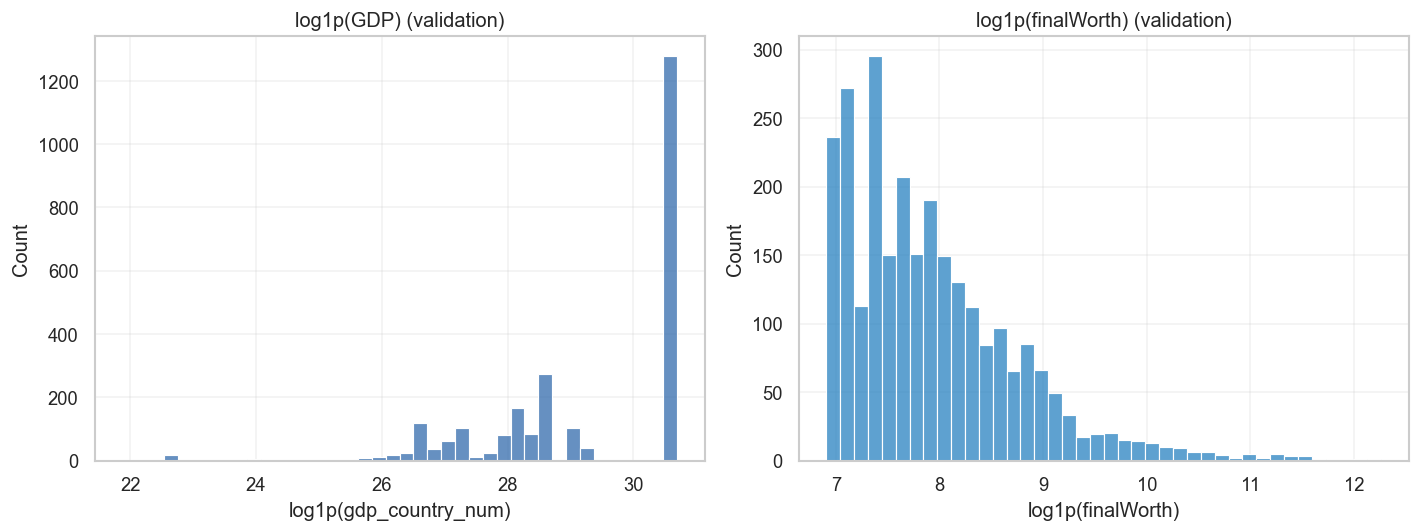

{'pdf': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M3_validation_log_distributions.pdf',
 'png': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M3_validation_log_distributions.png'}

In [85]:
# =======================================
# 3.4 Validation plots (quick sanity checks)
# =======================================
# These are not “final descriptive results”; they confirm that critical parsing/transformations behave as expected.

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))

# GDP (log) distribution
sns.histplot(df_clean["log_gdp"].dropna(), color=next_color(), bins=40, ax=axes[0], kde=False)
axes[0].set_title("log1p(GDP) (validation)")
axes[0].set_xlabel("log1p(gdp_country_num)")
axes[0].grid(alpha=0.25)

# Wealth (log) distribution
sns.histplot(df_clean["log_finalWorth"].dropna(), color=next_color(), bins=40, ax=axes[1], kde=False)
axes[1].set_title("log1p(finalWorth) (validation)")
axes[1].set_xlabel("log1p(finalWorth)")
axes[1].grid(alpha=0.25)

save_fig(fig, "fig_M3_validation_log_distributions")


### M3 Takeaways (report-ready)

**Core takeaways**
1. Cleaning is implemented as an **auditable, non-destructive** pipeline: `df_raw` remains unchanged and `df_clean` is produced with explicit type coercions and derived columns.
2. A **cleaning log** is exported, making every transformation reportable (and preventing “silent” changes to denominators).

**Exploratory / innovative takeaways**
1. Canonical columns (e.g., `category_canonical`) are introduced without dropping raw columns, allowing both reproducibility and cleaner downstream code.
2. Validation plots for `log_gdp` and `log_finalWorth` act as early anomaly detectors before formal descriptive/inferential steps.


### Adversarial review (M4)
- *Threat:* Descriptives on raw scale are dominated by the extreme right tail.
- *Threat:* Rankings and wealth levels can be misread without quantiles and concentration metrics.

**Design response:** report both raw and log views, emphasize medians/quantiles, and add top 1% concentration as a robustness-style descriptive check.


## Chapter 4 — Descriptive Statistics (Univariate) (M4)

**Goal of M4:** establish baseline descriptive facts about wealth distribution (heavy tails, concentration) and key group composition.

### Adversarial review
- “Are your descriptive conclusions robust to the top 1%?”
- “Are you mixing raw and log scales without clear interpretation?”

### Design response
- Report both raw and log summaries.
- Quantify concentration (e.g., top 1% share).
- Keep tables/figures report-ready with clear units and denominators.


## Chapter 4 — Descriptive Statistics (M4)
**Goal:** Answer RQ1 (heavy-tail + concentration) with report-ready tables and figures.
**Outputs:** distribution plots (raw/log), quantiles table, top 1% share, country/category summaries.


In [86]:
# =======================================
# 4.1 Summary statistics + quantiles (finalWorth)
# =======================================
# Reporting both raw and log summaries is essential for heavy-tailed outcomes.

y = df_clean["finalWorth"].dropna()
y_log = df_clean["log_finalWorth"].dropna()

def describe_with_quantiles(s: pd.Series, name: str) -> pd.DataFrame:
    qs = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    d = s.describe(percentiles=qs).to_frame(name).reset_index().rename(columns={"index": "stat"})
    return d

tab_y = describe_with_quantiles(y, "finalWorth")
tab_ylog = describe_with_quantiles(y_log, "log1p(finalWorth)")
tab_desc = tab_y.merge(tab_ylog, on="stat", how="outer")

save_table(tab_desc, "tab_M4_finalWorth_describe", index=False)


,stat,finalWorth,log1p(finalWorth)
0,1%,1000.000000,6.908755
1,10%,1200.000000,7.090910
2,25%,1500.000000,7.313887
3,5%,1100.000000,7.003974
4,50%,2300.000000,7.741099
5,75%,4200.000000,8.343078
6,90%,8000.000000,8.987322
7,95%,13320.000000,9.497076
8,99%,41808.000000,10.640328
9,count,2640.000000,2640.000000


{'csv': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M4_finalWorth_describe.csv',
 'tex': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M4_finalWorth_describe.tex'}

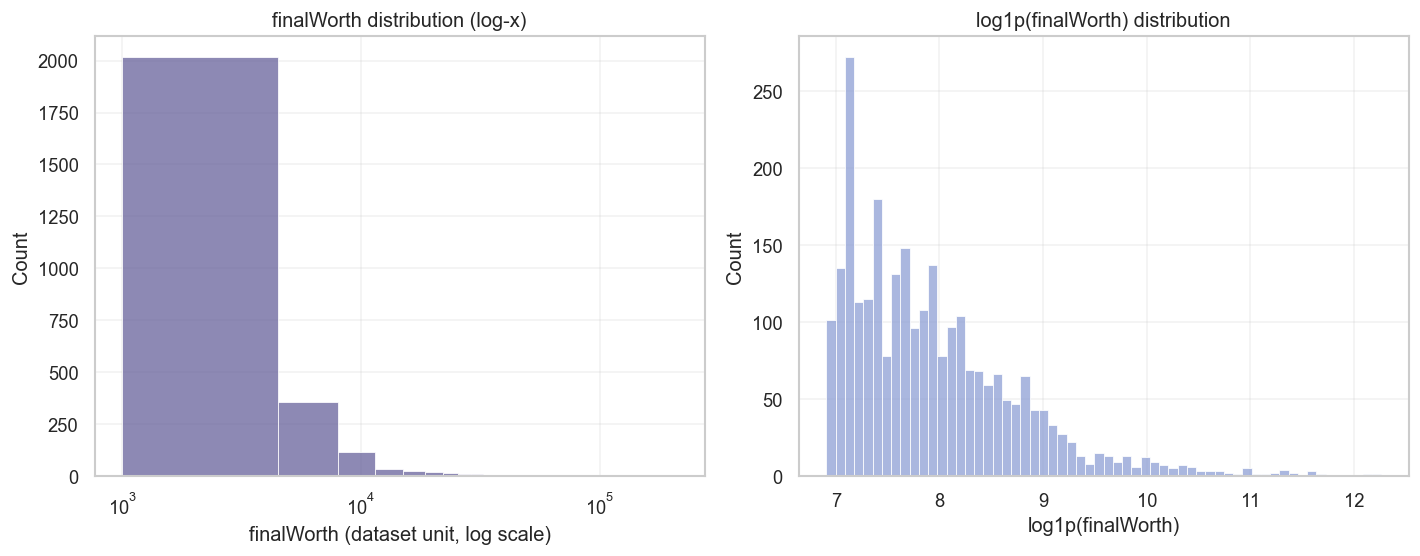

{'pdf': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M4_finalWorth_distribution_raw_and_log.pdf',
 'png': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M4_finalWorth_distribution_raw_and_log.png'}

In [87]:
# =======================================
# 4.2 Distribution plots (raw vs log)
# =======================================
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))

# Raw scale: use log-x to make the distribution visible without discarding extremes
sns.histplot(y, bins=60, ax=axes[0], color=next_color())
axes[0].set_xscale("log")
axes[0].set_title("finalWorth distribution (log-x)")
axes[0].set_xlabel("finalWorth (dataset unit, log scale)")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.25)

# Log scale distribution
sns.histplot(y_log, bins=60, ax=axes[1], color=next_color())
axes[1].set_title("log1p(finalWorth) distribution")
axes[1].set_xlabel("log1p(finalWorth)")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.25)

save_fig(fig, "fig_M4_finalWorth_distribution_raw_and_log")


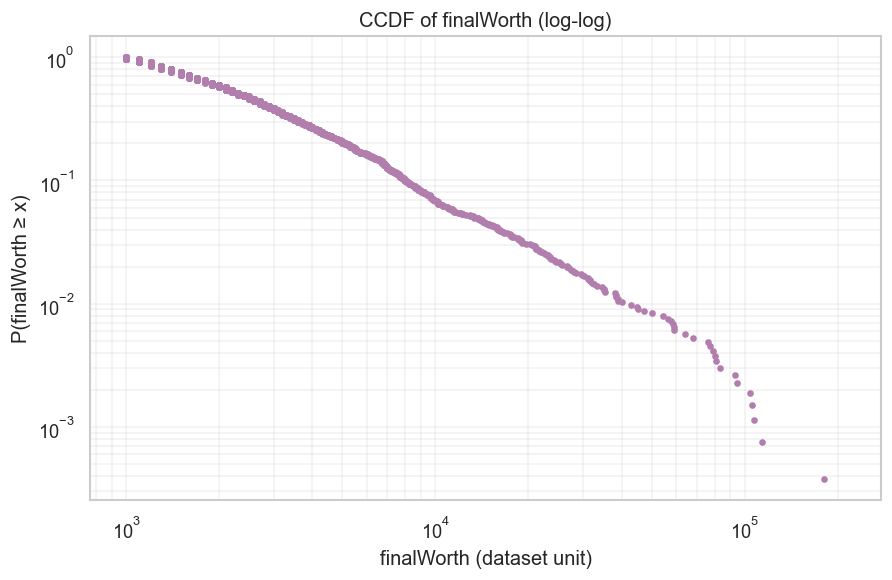

{'pdf': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M4_finalWorth_ccdf_loglog.pdf',
 'png': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M4_finalWorth_ccdf_loglog.png'}

In [88]:
# =======================================
# 4.3 CCDF (heavy-tail visualization)
# =======================================
# CCDF on log-log axes is a standard diagnostic for heavy tails.

x = y.sort_values().values
x = x[x > 0]
n = len(x)
ccdf = 1.0 - (np.arange(1, n + 1) / n)

fig, ax = plt.subplots(figsize=(7.6, 5.0))
ax.plot(x, ccdf, marker=".", linestyle="none", color=next_color())
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("CCDF of finalWorth (log-log)")
ax.set_xlabel("finalWorth (dataset unit)")
ax.set_ylabel("P(finalWorth ≥ x)")
ax.grid(alpha=0.25, which="both")
save_fig(fig, "fig_M4_finalWorth_ccdf_loglog")


,n_total,top_1pct_n,top_1pct_wealth_share,bottom_99pct_wealth_share
0,2640,27,0.179801,0.820199


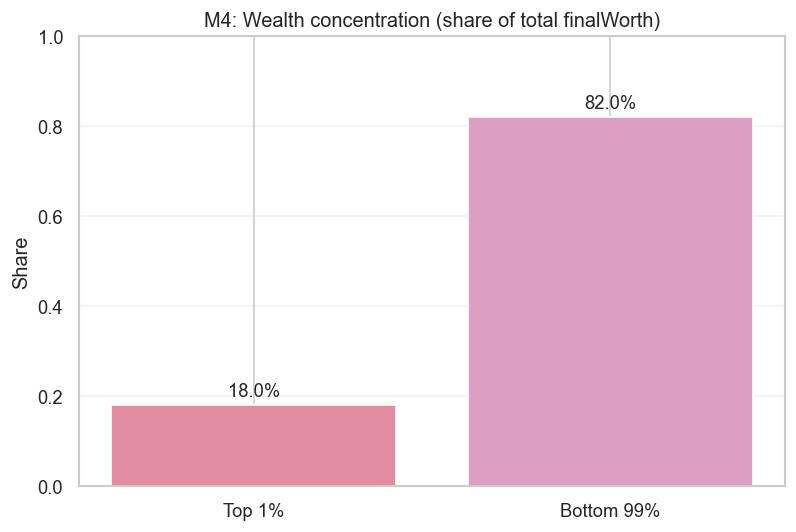

{'pdf': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M4_top1pct_wealth_share.pdf',
 'png': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M4_top1pct_wealth_share.png'}

In [89]:
# =======================================
# 4.4 Concentration: top 1% wealth share
# =======================================
x_desc = y.sort_values(ascending=False).values
n = len(x_desc)
k = max(1, int(np.ceil(0.01 * n)))

top_share = float(x_desc[:k].sum() / x_desc.sum())
rest_share = 1.0 - top_share

tab_conc = pd.DataFrame([{
    "n_total": n,
    "top_1pct_n": k,
    "top_1pct_wealth_share": top_share,
    "bottom_99pct_wealth_share": rest_share,
}])
save_table(tab_conc, "tab_M4_top1pct_wealth_share", index=False)

fig, ax = plt.subplots(figsize=(6.8, 4.6))
ax.bar(["Top 1%", "Bottom 99%"], [top_share, rest_share], color=[next_color(), next_color()])
ax.set_title("M4: Wealth concentration (share of total finalWorth)")
ax.set_ylabel("Share")
ax.set_ylim(0, 1.0)
for i, v in enumerate([top_share, rest_share]):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=11)
ax.grid(alpha=0.25, axis="y")
save_fig(fig, "fig_M4_top1pct_wealth_share")


,country,n,median_finalWorth,mean_finalWorth
74,United States,754,2900.0,6067.771883
16,China,523,1900.0,3452.198853
31,India,157,2100.0,4004.458599
26,Germany,102,2650.0,4530.392157
73,United Kingdom,82,2600.0,4520.731707
58,Russia,79,2500.0,4443.037975
65,Switzerland,78,3100.0,5255.128205
29,Hong Kong,68,2700.0,4727.941176
35,Italy,55,2300.0,2852.727273
59,Singapore,46,2150.0,3000.000000


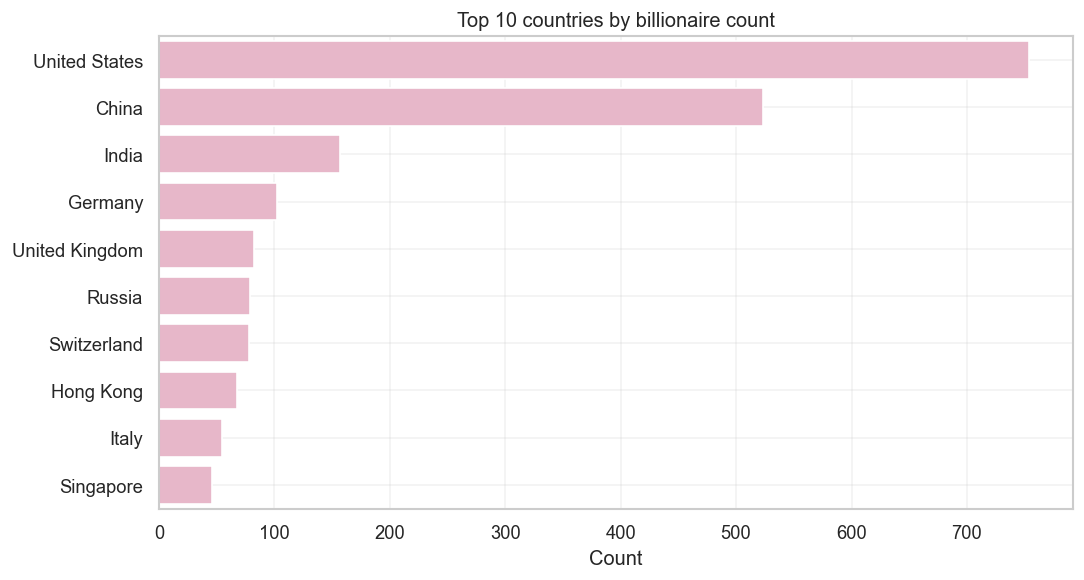

,category,n,median_finalWorth,mean_finalWorth
5,Finance & Investments,372,2600.0,4314.784946
10,Manufacturing,324,2000.0,3145.061728
16,Technology,314,2200.0,5980.573248
4,Fashion & Retail,266,2500.0,6386.466165
6,Food & Beverage,212,2500.0,4515.094340
8,Healthcare,201,2100.0,3200.000000
13,Real Estate,193,2300.0,3406.217617
2,Diversified,187,2300.0,4840.641711
3,Energy,100,2450.0,4535.000000
11,Media & Entertainment,91,2500.0,4697.802198


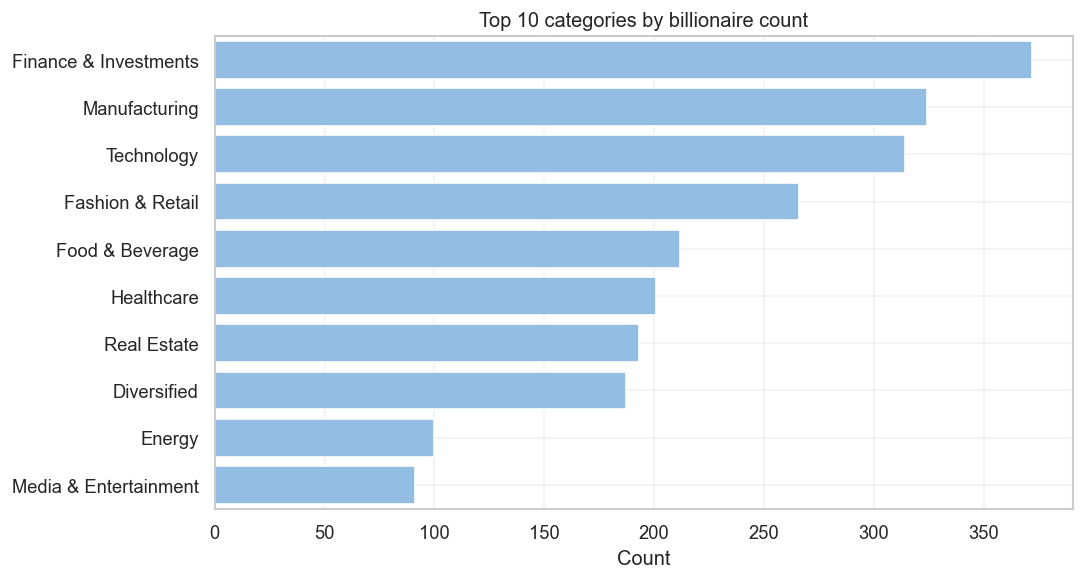

In [90]:
# =======================================
# 4.5 Top groups (counts and median wealth)
# =======================================
def topk_table(df_in: pd.DataFrame, group: str, k: int = 10) -> pd.DataFrame:
    g = df_in.groupby(group, dropna=False).agg(
        n=("finalWorth", "size"),
        median_finalWorth=("finalWorth", "median"),
        mean_finalWorth=("finalWorth", "mean"),
    ).reset_index()
    g = g.sort_values("n", ascending=False).head(k)
    return g

# Top countries by count
if "country" in df_clean.columns:
    top_country = topk_table(df_clean, "country", k=10)
    save_table(top_country, "tab_M4_top10_country_by_count", index=False)

    fig, ax = plt.subplots(figsize=(9.2, 5.0))
    sns.barplot(data=top_country, y="country", x="n", ax=ax, color=next_color())
    ax.set_title("Top 10 countries by billionaire count")
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    ax.grid(alpha=0.25)
    save_fig(fig, "fig_M4_top10_country_count")
else:
    display(pd.DataFrame([{"note": "country column not found"}]))

# Top categories by count (canonical)
if "category_canonical" in df_clean.columns:
    top_cat = topk_table(df_clean, "category_canonical", k=10)
    top_cat = top_cat.rename(columns={"category_canonical": "category"})
    save_table(top_cat, "tab_M4_top10_category_by_count", index=False)

    fig, ax = plt.subplots(figsize=(9.2, 5.0))
    sns.barplot(data=top_cat, y="category", x="n", ax=ax, color=next_color())
    ax.set_title("Top 10 categories by billionaire count")
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    ax.grid(alpha=0.25)
    save_fig(fig, "fig_M4_top10_category_count")
else:
    display(pd.DataFrame([{"note": "category_canonical not found"}]))


### M4 Takeaways (report-ready; addresses RQ1)

**Core takeaways**
1. `finalWorth` is heavy-tailed: the raw distribution requires log-scale visualization and log-transformed summaries to avoid dominance by extreme values.
2. Wealth concentration is substantial; the **top 1% share** provides a transparent, reportable measure of how sensitive means/variances/regression may be to the ultra-wealthy tail.

**Exploratory / innovative takeaways**
1. CCDF (log-log) is an interpretable heavy-tail diagnostic that can justify robustness checks (e.g., trimming/winsorization) later in M8.
2. Top-group composition (country/category) provides a baseline for stratified inference and helps identify where missingness/outliers might have the largest downstream impact.


## Chapter 5 — EDA (Bivariate / Stratified / Multivariate) (M5)

**Goal (M5):** explore *bivariate* and *stratified* relationships to (i) choose inferential tests and (ii) anticipate Simpson’s paradox / confounding for regression.

**Minimum deliverables (per workbook):**
- `fig_M5_scatter_finalWorth_vs_gdp_raw`
- `fig_M5_scatter_logWorth_vs_logGDP`
- `fig_M5_box_logWorth_by_selfMade`, `fig_M5_box_logWorth_by_gender`
- `fig_M5_corr_heatmap_spearman`
- ≥2 **core takeaways** + ≥2 **exploratory takeaways**


In [91]:
# =======================================
# M5.1 EDA helpers (plotting + safe subsets)
# =======================================

def _coerce_boolish(series: pd.Series) -> pd.Series:
    """Normalize common boolean encodings (0/1, True/False, yes/no) to {0,1,NA}."""
    s = series.copy()
    if pd.api.types.is_bool_dtype(s):
        return s.astype("Int64")
    # common numeric encodings
    if pd.api.types.is_numeric_dtype(s):
        return s.round().astype("Int64")
    # string encodings
    s = s.astype(str).str.strip().str.lower().replace({"nan": np.nan})
    mapping = {
        "1": 1, "true": 1, "yes": 1, "y": 1, "t": 1,
        "0": 0, "false": 0, "no": 0, "n": 0, "f": 0,
    }
    return s.map(mapping).astype("Int64")

def scatter(df: pd.DataFrame, x: str, y: str, *, hue: Optional[str] = None,
            logx: bool = False, logy: bool = False, title: str = "",
            note: Optional[str] = None) -> mpl.figure.Figure:
    """Scatter with consistent aesthetics; supports log axes (for heavy tails)."""
    d = df[[x, y] + ([hue] if hue else [])].dropna().copy()
    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    base_color = COLOR["primary"] if hue is None else None

    if hue is None:
        ax.scatter(d[x], d[y], s=18, alpha=0.28, c=base_color, edgecolors="none")
    else:
        # For legibility: limit hue levels if too many
        if d[hue].nunique(dropna=True) > 12:
            top_levels = d[hue].value_counts().head(12).index
            d = d[d[hue].isin(top_levels)].copy()
        sns.scatterplot(data=d, x=x, y=y, hue=hue, palette=PALETTE, s=30, alpha=0.55, ax=ax, edgecolor=None)

    # Add a robust trend line (on the *plotted* scale)
    try:
        sns.regplot(data=d, x=x, y=y, scatter=False, lowess=True,
                    line_kws={"lw": 2.0, "color": COLOR["secondary"]}, ax=ax)
    except Exception:
        pass

    if logx:
        ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")

    ax.set_title(title)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    if note:
        ax.text(0.02, 0.02, note, transform=ax.transAxes, fontsize=9, va="bottom", ha="left",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.9))
    return fig

def boxplot(df: pd.DataFrame, y: str, group: str, *, title: str = "", order: Optional[List[str]] = None) -> mpl.figure.Figure:
    d = df[[y, group]].dropna().copy()
    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    sns.boxplot(data=d, x=group, y=y, order=order, ax=ax, palette=PALETTE, showfliers=False)
    sns.stripplot(data=d, x=group, y=y, order=order, ax=ax, color="0.25", alpha=0.25, size=2.5, jitter=0.25)
    ax.set_title(title)
    ax.set_xlabel(group)
    ax.set_ylabel(y)
    return fig

def spearman_heatmap(df: pd.DataFrame, cols: List[str], *, title: str = "") -> mpl.figure.Figure:
    use = [c for c in cols if c in df.columns]
    d = df[use].copy()
    d = d.apply(pd.to_numeric, errors="coerce")
    corr = d.corr(method="spearman")
    fig, ax = plt.subplots(figsize=(8.2, 6.2))
    sns.heatmap(corr, cmap=CMAP_PRIMARY, center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
                linewidths=0.5, cbar_kws={"label": "Spearman correlation"}, ax=ax)
    ax.set_title(title)
    return fig, corr


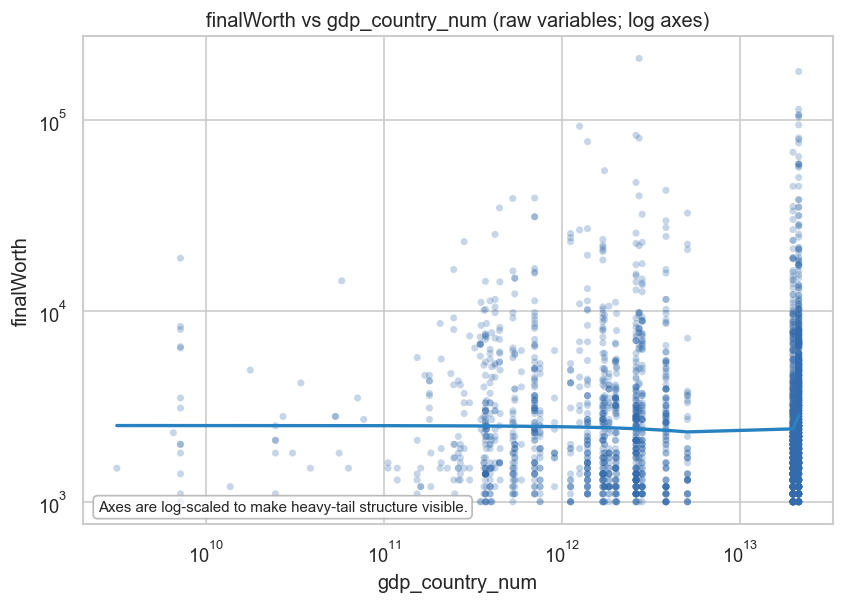

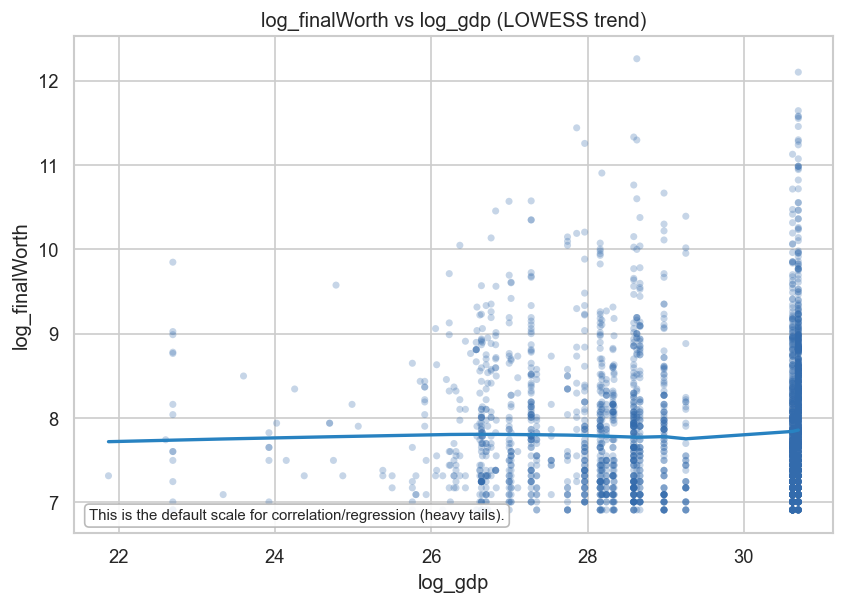

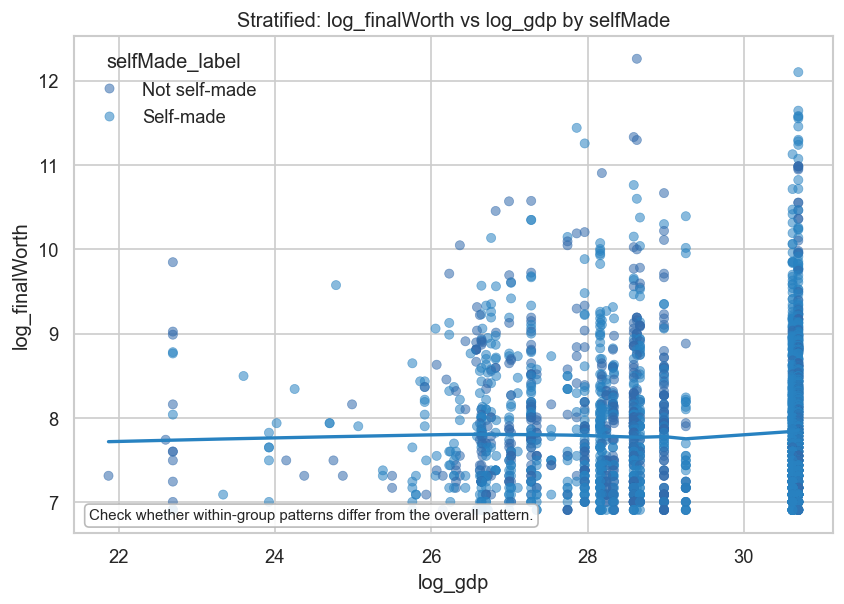

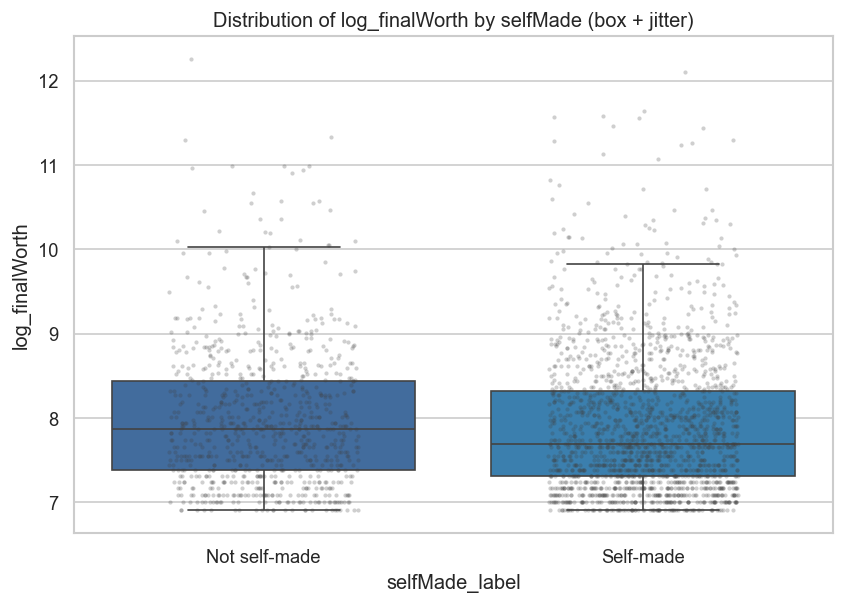

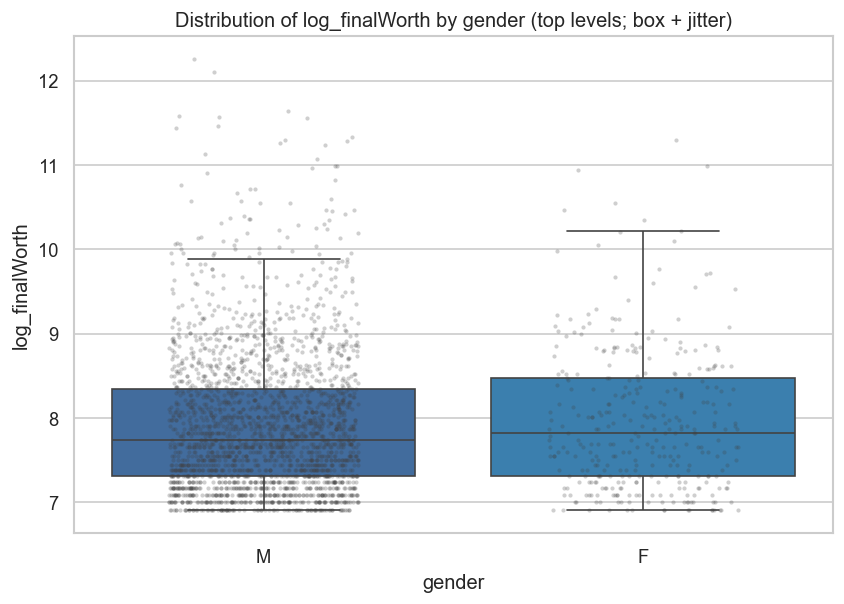

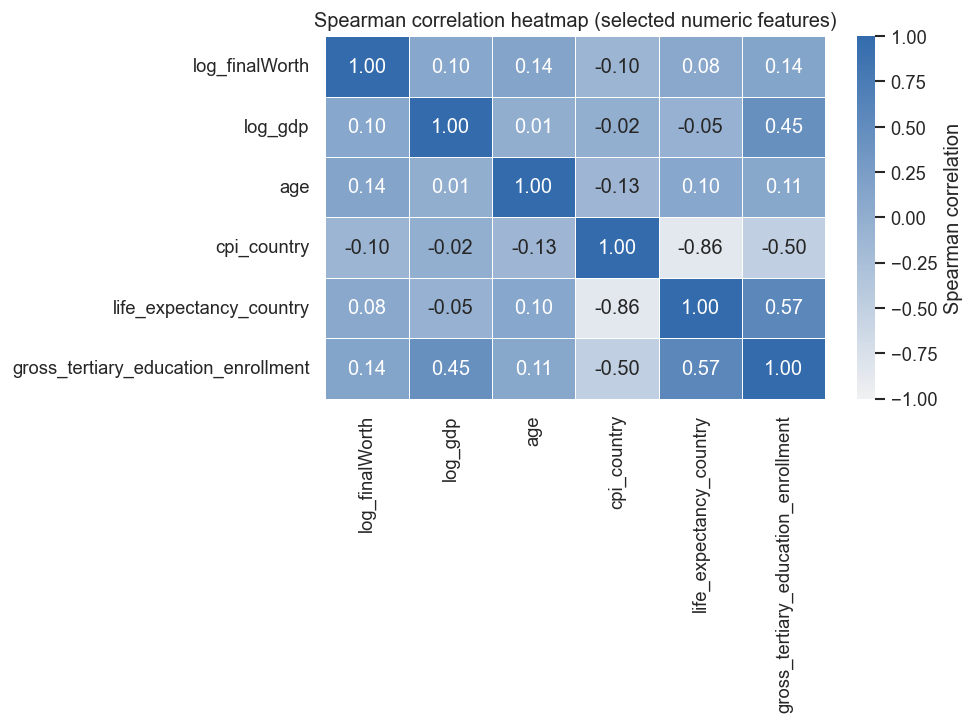

,variable,log_finalWorth,log_gdp,age,cpi_country,life_expectancy_country,gross_tertiary_education_enrollment
0,log_finalWorth,1.000000,0.096573,0.144039,-0.104249,0.084260,0.137406
1,log_gdp,0.096573,1.000000,0.005440,-0.021747,-0.048628,0.452886
2,age,0.144039,0.005440,1.000000,-0.125774,0.100373,0.105191
3,cpi_country,-0.104249,-0.021747,-0.125774,1.000000,-0.859476,-0.498725
4,life_expectancy_country,0.084260,-0.048628,0.100373,-0.859476,1.000000,0.572568
5,gross_tertiary_education_enrollment,0.137406,0.452886,0.105191,-0.498725,0.572568,1.000000


,slice,n,pearson_r,spearman_r
0,Overall (complete cases),2476,0.045759,0.096573
9,category=Diversified,182,0.071743,0.119415
6,category=Fashion & Retail,252,0.064775,0.088260
3,category=Finance & Investments,345,0.136928,0.178481
7,category=Food & Beverage,201,-0.036885,0.049971
8,category=Healthcare,197,-0.069842,-0.069674
5,category=Manufacturing,298,-0.150761,-0.069781
10,category=Real Estate,162,0.217277,0.290688
4,category=Technology,299,0.090093,0.093944
2,selfMade=Not self-made,755,0.125791,0.150643


{'csv': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M5_groupwise_correlations.csv',
 'tex': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M5_groupwise_correlations.tex'}

In [92]:
# =======================================
# M5.2 Bivariate & stratified EDA
# =======================================

# Guardrails: require df_clean
assert "df_clean" in globals(), "df_clean not found. Run Chapter 3 (M3) first."

# Core variables
need_cols = ["finalWorth", "gdp_country_num", "log_finalWorth", "log_gdp", "selfMade", "gender", "category", "country"]
available = [c for c in need_cols if c in df_clean.columns]
df_eda = df_clean[available].copy()

# Normalize selfMade to a compact label (for plots/tables)
if "selfMade" in df_eda.columns:
    df_eda["selfMade_bin"] = _coerce_boolish(df_eda["selfMade"])
    df_eda["selfMade_label"] = df_eda["selfMade_bin"].map({1: "Self-made", 0: "Not self-made"}).astype("object")

# ---- 1) Scatter: finalWorth vs gdp (raw variables; log axes for readability)
if {"finalWorth","gdp_country_num"}.issubset(df_eda.columns):
    fig = scatter(
        df_eda, "gdp_country_num", "finalWorth",
        logx=True, logy=True,
        title="finalWorth vs gdp_country_num (raw variables; log axes)",
        note="Axes are log-scaled to make heavy-tail structure visible."
    )
    save_fig(fig, "fig_M5_scatter_finalWorth_vs_gdp_raw")

# ---- 2) Scatter: logWorth vs logGDP (preferred scale for inference/regression)
if {"log_finalWorth","log_gdp"}.issubset(df_eda.columns):
    fig = scatter(
        df_eda, "log_gdp", "log_finalWorth",
        title="log_finalWorth vs log_gdp (LOWESS trend)",
        note="This is the default scale for correlation/regression (heavy tails)."
    )
    save_fig(fig, "fig_M5_scatter_logWorth_vs_logGDP")

# ---- 3) Stratified scatter (Simpson risk check): hue by selfMade
if {"log_finalWorth","log_gdp","selfMade_label"}.issubset(df_eda.columns):
    fig = scatter(
        df_eda, "log_gdp", "log_finalWorth",
        hue="selfMade_label",
        title="Stratified: log_finalWorth vs log_gdp by selfMade",
        note="Check whether within-group patterns differ from the overall pattern."
    )
    save_fig(fig, "fig_M5_scatter_logWorth_vs_logGDP_by_selfMade")

# ---- 4) Group contrasts (visual): boxplots
if {"log_finalWorth","selfMade_label"}.issubset(df_eda.columns):
    fig = boxplot(df_eda, "log_finalWorth", "selfMade_label",
                  title="Distribution of log_finalWorth by selfMade (box + jitter)")
    save_fig(fig, "fig_M5_box_logWorth_by_selfMade")

if {"log_finalWorth","gender"}.issubset(df_eda.columns):
    # Keep top levels only (typically 'M'/'F')
    top_g = df_eda["gender"].value_counts().head(4).index.tolist()
    dtmp = df_eda[df_eda["gender"].isin(top_g)].copy()
    fig = boxplot(dtmp, "log_finalWorth", "gender",
                  title="Distribution of log_finalWorth by gender (top levels; box + jitter)",
                  order=top_g)
    save_fig(fig, "fig_M5_box_logWorth_by_gender")

# ---- 5) Spearman correlation heatmap (numeric features; auto-filter)
candidate_numeric = [
    "log_finalWorth", "log_gdp", "age",
    "cpi_country", "gini_country", "tax_revenue_country",
    "life_expectancy_country", "education_enrolment_tertiary",
    "gross_tertiary_education_enrollment"
]
fig_corr, corr = spearman_heatmap(df_clean, candidate_numeric, title="Spearman correlation heatmap (selected numeric features)")
save_fig(fig_corr, "fig_M5_corr_heatmap_spearman")
save_table(corr.reset_index().rename(columns={"index":"variable"}), "tab_M5_corr_matrix_spearman", index=False)

# ---- 6) Group-wise correlations (overall vs stratified by selfMade/category)
rows = []
if {"log_finalWorth","log_gdp"}.issubset(df_clean.columns):
    d = df_clean[["log_finalWorth","log_gdp"]].dropna()
    rows.append({"slice": "Overall (complete cases)", "n": len(d),
                 "pearson_r": d["log_finalWorth"].corr(d["log_gdp"], method="pearson"),
                 "spearman_r": d["log_finalWorth"].corr(d["log_gdp"], method="spearman")})

if {"log_finalWorth","log_gdp","selfMade"}.issubset(df_clean.columns):
    tmp = df_clean[["log_finalWorth","log_gdp","selfMade"]].dropna().copy()
    tmp["selfMade_bin"] = _coerce_boolish(tmp["selfMade"])
    for v, lab in [(1,"Self-made"), (0,"Not self-made")]:
        dv = tmp[tmp["selfMade_bin"]==v][["log_finalWorth","log_gdp"]]
        if len(dv) >= 30:
            rows.append({"slice": f"selfMade={lab}", "n": len(dv),
                         "pearson_r": dv["log_finalWorth"].corr(dv["log_gdp"], method="pearson"),
                         "spearman_r": dv["log_finalWorth"].corr(dv["log_gdp"], method="spearman")})

if {"log_finalWorth","log_gdp","category"}.issubset(df_clean.columns):
    tmp = df_clean[["log_finalWorth","log_gdp","category"]].dropna()
    top_cat = tmp["category"].value_counts().head(8).index
    for c in top_cat:
        dv = tmp[tmp["category"]==c][["log_finalWorth","log_gdp"]]
        if len(dv) >= 30:
            rows.append({"slice": f"category={c}", "n": len(dv),
                         "pearson_r": dv["log_finalWorth"].corr(dv["log_gdp"], method="pearson"),
                         "spearman_r": dv["log_finalWorth"].corr(dv["log_gdp"], method="spearman")})

tab = pd.DataFrame(rows).sort_values(["slice"])
save_table(tab, "tab_M5_groupwise_correlations", index=False)


### M5 Takeaways (report-ready)

**Core takeaways**
1. The relationship between **wealth and GDP is far more interpretable on the log–log scale**, consistent with heavy-tailed variables (supports the design choice for M6/M7).
2. Stratified views (e.g., by **selfMade**) should be checked before inference: *overall* association can mask *within-group* heterogeneity (Simpson risk).

**Exploratory takeaways**
1. Group-wise correlations by **category** can differ meaningfully, motivating stratified robustness checks (M8) and/or controls in regression (M7).
2. Visual contrasts (boxplots) suggest potential differences across **selfMade** and possibly **gender**, which will be formalized with effect sizes + CI in M6.


## Chapter 6 — Inferential Statistics (Tests + Effect Size + CI) (M6)

**Goal (M6):** satisfy the inferential requirement with *research-grade reporting*:
- correlation (Pearson + Spearman) with **bootstrap CI**
- ≥2 hypothesis tests with **effect size + CI** (p-values as supporting evidence)
- ≥1 **robustness check** for a key conclusion (e.g., permutation test / drop top 1%)

**Deliverables:**
- `tab_M6_inferential_results` (test / effect size / CI / p / interpretation)
- `fig_M6_effectsize_forest` (effect sizes with CIs)


### Statistical Notes (M6)

**Correlation (association, not causation).**
Let $(x_i, y_i)$ denote paired observations.
- Pearson correlation:
$$
r=\frac{\sum_i (x_i-\bar x)(y_i-\bar y)}{\sqrt{\sum_i (x_i-\bar x)^2}\sqrt{\sum_i (y_i-\bar y)^2}}
$$
- Spearman correlation is Pearson correlation computed on rank-transformed variables.

**Two-group effect sizes.**
Let group means be $\bar x_1,\bar x_0$ and sample variances $s_1^2,s_0^2$.
- Mean difference: $\Delta=\bar x_1-\bar x_0$.
- Cohen's $d$ (standardized mean difference):
$$
d=\frac{\bar x_1-\bar x_0}{s_p},\quad
s_p=\sqrt{\frac{(n_1-1)s_1^2+(n_0-1)s_0^2}{n_1+n_0-2}}
$$
- Cliff’s $\delta$ measures stochastic dominance:
$$
\delta = P(X_1>X_0)-P(X_1<X_0)
$$

**Bootstrap confidence intervals.**
We use nonparametric bootstrap by resampling observations with replacement to form a 95% CI
from the empirical quantiles (2.5%, 97.5%).

In [93]:
# =======================================
# M6.1 Inferential helpers (effect sizes + CI)
# =======================================

RNG = np.random.default_rng(42)

def bootstrap_ci(stat_fn, data, *, n_boot: int = 2000, alpha: float = 0.05):
    """Generic bootstrap CI (percentile) for a statistic."""
    stats_ = []
    n = len(data)
    for _ in range(n_boot):
        idx = RNG.integers(0, n, size=n)
        stats_.append(stat_fn(data[idx]))
    lo, hi = np.quantile(stats_, [alpha/2, 1-alpha/2])
    return float(lo), float(hi)

def bootstrap_ci_2groups(stat_fn, x, y, *, n_boot: int = 2000, alpha: float = 0.05):
    stats_ = []
    x = np.asarray(x); y = np.asarray(y)
    nx, ny = len(x), len(y)
    for _ in range(n_boot):
        xb = x[RNG.integers(0, nx, size=nx)]
        yb = y[RNG.integers(0, ny, size=ny)]
        stats_.append(stat_fn(xb, yb))
    lo, hi = np.quantile(stats_, [alpha/2, 1-alpha/2])
    return float(lo), float(hi)

def cohens_d(x, y) -> float:
    x = np.asarray(x); y = np.asarray(y)
    nx, ny = len(x), len(y)
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    pooled = ((nx-1)*vx + (ny-1)*vy) / (nx + ny - 2)
    return float((x.mean() - y.mean()) / np.sqrt(pooled))

def cliffs_delta(x, y) -> float:
    """Cliff's delta in [-1,1], robust to non-normality."""
    x = np.asarray(x); y = np.asarray(y)
    # O(nm) exact; acceptable at typical sample sizes; for large, consider approximation.
    greater = sum((xi > y).sum() for xi in x)
    less = sum((xi < y).sum() for xi in x)
    return float((greater - less) / (len(x)*len(y)))

def perm_test_diff_means(x, y, *, n_perm: int = 2000) -> float:
    """Two-sided permutation test for difference in means."""
    x = np.asarray(x); y = np.asarray(y)
    obs = x.mean() - y.mean()
    pooled = np.concatenate([x, y])
    nx = len(x)
    more_extreme = 0
    for _ in range(n_perm):
        RNG.shuffle(pooled)
        diff = pooled[:nx].mean() - pooled[nx:].mean()
        if abs(diff) >= abs(obs):
            more_extreme += 1
    return (more_extreme + 1) / (n_perm + 1)

def corr_bootstrap_ci(x, y, method: str = "spearman", *, n_boot: int = 2000, alpha: float = 0.05):
    x = np.asarray(x); y = np.asarray(y)
    n = len(x)
    def stat(idx):
        xx = x[idx]; yy = y[idx]
        if method == "pearson":
            return np.corrcoef(xx, yy)[0,1]
        else:
            return stats.spearmanr(xx, yy, nan_policy="omit").correlation
    boots = []
    for _ in range(n_boot):
        idx = RNG.integers(0, n, size=n)
        boots.append(stat(idx))
    lo, hi = np.quantile(boots, [alpha/2, 1-alpha/2])
    return float(lo), float(hi)


,group_a,group_b,n_a,n_b,cliffs_delta,ci_low,ci_high,p_raw,p_fdr_bh,reject_fdr05
0,Finance & Investments,Manufacturing,372,324,0.176142,0.098139,0.257358,0.000060,0.001100,True
8,Manufacturing,Fashion & Retail,324,266,-0.188689,-0.285856,-0.102522,0.000079,0.001100,True
4,Finance & Investments,Healthcare,372,201,0.159324,0.061792,0.249185,0.001628,0.011394,True
19,Fashion & Retail,Healthcare,266,201,0.170258,0.068434,0.262275,0.001615,0.011394,True
9,Manufacturing,Food & Beverage,324,212,-0.153739,-0.248842,-0.056910,0.002584,0.014468,True
7,Manufacturing,Technology,324,314,-0.132932,-0.218992,-0.044692,0.003652,0.017040,True
12,Manufacturing,Diversified,324,187,-0.133706,-0.220579,-0.032776,0.011711,0.046845,True
22,Food & Beverage,Healthcare,212,201,0.133695,0.012023,0.248895,0.018756,0.065645,False
11,Manufacturing,Real Estate,324,193,-0.119715,-0.213322,-0.025409,0.022632,0.070411,False
15,Technology,Healthcare,314,201,0.112495,0.014607,0.205279,0.031093,0.087061,False


,family,analysis,n,effect,ci_low,ci_high,p_value
0,Correlation,"Pearson r (logWorth, logGDP)",2476,0.045759,0.007066,0.082935,0.022786
1,Correlation,"Spearman ρ (logWorth, logGDP)",2476,0.096573,0.057546,0.136319,0.000001
2,Two-group,Welch t-test: selfMade vs not (logWorth),2640,-0.097502,-0.168643,-0.031732,0.004980
3,Two-group,Cohen's d: selfMade vs not (logWorth),2640,-0.118971,-0.201232,-0.034527,0.004980
4,Two-group,Cliff's delta: selfMade vs not (logWorth),2640,-0.079194,-0.124112,-0.031179,0.001072
5,Robustness,"Permutation p-value (mean diff, logWorth)",2640,NaN,NaN,NaN,0.004998
6,Multi-group,Kruskal–Wallis: logWorth across category,2640,0.008831,NaN,NaN,0.001030


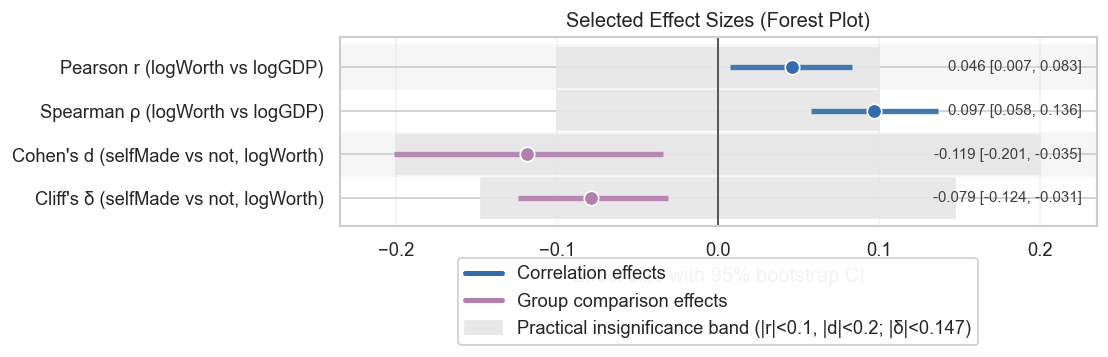

{'pdf': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M6_effectsize_forest.pdf',
 'png': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M6_effectsize_forest.png'}

In [94]:
# =======================================
# M6.2 Correlation + hypothesis tests (effect size + CI)
# =======================================

assert "df_clean" in globals(), "df_clean not found. Run M3 first."

results = []

# ---- A) Correlation: log_finalWorth vs log_gdp (Pearson + Spearman + bootstrap CI)
if {"log_finalWorth","log_gdp"}.issubset(df_clean.columns):
    d = df_clean[["log_finalWorth","log_gdp"]].dropna()
    x = d["log_gdp"].to_numpy()
    y = d["log_finalWorth"].to_numpy()

    pear = np.corrcoef(x, y)[0,1]
    spea = stats.spearmanr(x, y, nan_policy="omit").correlation
    pear_ci = corr_bootstrap_ci(x, y, method="pearson")
    spea_ci = corr_bootstrap_ci(x, y, method="spearman")

    results += [
        {"family": "Correlation", "analysis": "Pearson r (logWorth, logGDP)", "n": len(d),
         "effect": pear, "ci_low": pear_ci[0], "ci_high": pear_ci[1], "p_value": stats.pearsonr(x, y).pvalue},
        {"family": "Correlation", "analysis": "Spearman ρ (logWorth, logGDP)", "n": len(d),
         "effect": spea, "ci_low": spea_ci[0], "ci_high": spea_ci[1], "p_value": stats.spearmanr(x, y).pvalue},
    ]

# ---- B) Two-group test: selfMade vs not (log_finalWorth)
if {"log_finalWorth","selfMade"}.issubset(df_clean.columns):
    tmp = df_clean[["log_finalWorth","selfMade"]].dropna().copy()
    tmp["selfMade_bin"] = _coerce_boolish(tmp["selfMade"])
    g1 = tmp[tmp["selfMade_bin"]==1]["log_finalWorth"].to_numpy()
    g0 = tmp[tmp["selfMade_bin"]==0]["log_finalWorth"].to_numpy()

    if len(g1) >= 30 and len(g0) >= 30:
        # Welch t-test
        t = stats.ttest_ind(g1, g0, equal_var=False)
        d_eff = cohens_d(g1, g0)
        d_ci = bootstrap_ci_2groups(cohens_d, g1, g0)
        mean_diff = float(g1.mean() - g0.mean())
        mean_ci = bootstrap_ci_2groups(lambda a,b: a.mean()-b.mean(), g1, g0)

        # Mann–Whitney U (nonparam) + Cliff's delta
        u = stats.mannwhitneyu(g1, g0, alternative="two-sided")
        cd = cliffs_delta(g1, g0)
        cd_ci = bootstrap_ci_2groups(cliffs_delta, g1, g0)

        # Permutation test as robustness check
        p_perm = perm_test_diff_means(g1, g0)

        results += [
            {"family": "Two-group", "analysis": "Welch t-test: selfMade vs not (logWorth)", "n": len(tmp),
             "effect": mean_diff, "ci_low": mean_ci[0], "ci_high": mean_ci[1], "p_value": t.pvalue},
            {"family": "Two-group", "analysis": "Cohen's d: selfMade vs not (logWorth)", "n": len(tmp),
             "effect": d_eff, "ci_low": d_ci[0], "ci_high": d_ci[1], "p_value": t.pvalue},
            {"family": "Two-group", "analysis": "Cliff's delta: selfMade vs not (logWorth)", "n": len(tmp),
             "effect": cd, "ci_low": cd_ci[0], "ci_high": cd_ci[1], "p_value": u.pvalue},
            {"family": "Robustness", "analysis": "Permutation p-value (mean diff, logWorth)", "n": len(tmp),
             "effect": np.nan, "ci_low": np.nan, "ci_high": np.nan, "p_value": p_perm},
        ]

# ---- C) Multi-group test: category differences (log_finalWorth) via Kruskal–Wallis
if {"log_finalWorth","category"}.issubset(df_clean.columns):
    tmp = df_clean[["log_finalWorth","category"]].dropna()
    # Use categories with sufficient sample size
    counts = tmp["category"].value_counts()
    use_cats = counts[counts >= 30].index.tolist()
    groups = [tmp[tmp["category"]==c]["log_finalWorth"].to_numpy() for c in use_cats]
    if len(groups) >= 3:
        kw = stats.kruskal(*groups)
        n = len(tmp); k = len(groups)
        # epsilon-squared for Kruskal–Wallis
        eps2 = (kw.statistic - k + 1) / (n - k)
        results.append({"family":"Multi-group", "analysis":"Kruskal–Wallis: logWorth across category", "n": n,
                        "effect": float(eps2), "ci_low": np.nan, "ci_high": np.nan, "p_value": kw.pvalue})

        # Post-hoc (top categories): pairwise Mann–Whitney with BH-FDR
        top_cats = counts.head(8).index.tolist()
        pairs = []
        pvals = []
        for i in range(len(top_cats)):
            for j in range(i+1, len(top_cats)):
                a = tmp[tmp["category"]==top_cats[i]]["log_finalWorth"].to_numpy()
                b = tmp[tmp["category"]==top_cats[j]]["log_finalWorth"].to_numpy()
                if len(a)>=30 and len(b)>=30:
                    u = stats.mannwhitneyu(a,b,alternative="two-sided")
                    cd = cliffs_delta(a,b)
                    cd_ci = bootstrap_ci_2groups(cliffs_delta, a, b, n_boot=400)
                    pairs.append({
                        "group_a": top_cats[i], "group_b": top_cats[j],
                        "n_a": len(a), "n_b": len(b),
                        "cliffs_delta": cd, "ci_low": cd_ci[0], "ci_high": cd_ci[1],
                        "p_raw": u.pvalue,
                    })
                    pvals.append(u.pvalue)
        if pairs:
            rej, p_adj, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")
            for row, padj, rj in zip(pairs, p_adj, rej):
                row["p_fdr_bh"] = padj
                row["reject_fdr05"] = bool(rj)
            tab_pairs = pd.DataFrame(pairs).sort_values("p_fdr_bh")
            save_table(tab_pairs, "tab_M6_posthoc_category_pairwise", index=False)

# ---- Compile inferential results table
tab_res = pd.DataFrame(results)
# Formatting: keep raw numeric; formatting can be done in LaTeX/report later
save_table(tab_res, "tab_M6_inferential_results", index=False)

# ---- Effect-size forest plot (selected headline effects) [Add practical insignificance bands]
forest_rows = []
for _, r in tab_res.iterrows():
    s = str(r["analysis"])
    if s.startswith("Spearman") or s.startswith("Pearson") or s.startswith("Cohen") or s.startswith("Cliff"):
        forest_rows.append(r)

forest = pd.DataFrame(forest_rows).dropna(subset=["effect"]).copy()

if len(forest) > 0:
    # Cleaner labels + grouping
    def _short_label(s: str) -> str:
        if s.startswith("Pearson"):
            return "Pearson r (logWorth vs logGDP)"
        if s.startswith("Spearman"):
            return "Spearman ρ (logWorth vs logGDP)"
        if s.startswith("Cohen"):
            return "Cohen's d (selfMade vs not, logWorth)"
        if s.startswith("Cliff"):
            return "Cliff's δ (selfMade vs not, logWorth)"
        return s

    forest["label"] = forest["analysis"].astype(str).map(_short_label)
    forest["group"] = np.where(
        forest["analysis"].astype(str).str.startswith(("Pearson", "Spearman")),
        "Correlation",
        "Group comparison"
    )

    # Practical insignificance thresholds by effect type
    # Requested: |r|<0.1, |d|<0.2. For Cliff's delta, use a common negligible threshold |δ|<0.147.
    def _practical_thr(s: str) -> float:
        if s.startswith(("Pearson", "Spearman")):
            return 0.10
        if s.startswith("Cohen"):
            return 0.20
        if s.startswith("Cliff"):
            return 0.147  # optional; remove if you don't want a band for Cliff's delta
        return np.nan

    forest["thr"] = forest["analysis"].astype(str).map(_practical_thr)

    # Order: Correlation first, then Group comparison
    order = []
    for g in ["Correlation", "Group comparison"]:
        order += forest.loc[forest["group"] == g, "label"].tolist()
    seen = set()
    order = [x for x in order if not (x in seen or seen.add(x))]

    forest["label"] = pd.Categorical(forest["label"], categories=order, ordered=True)
    forest = forest.sort_values(["group", "label"]).reset_index(drop=True)

    # Determine x-limits with padding (symmetric around 0 looks nicer for signed effects)
    x_min = np.nanmin(forest["ci_low"].to_numpy())
    x_max = np.nanmax(forest["ci_high"].to_numpy())
    pad = 0.10 * (x_max - x_min + 1e-9)
    lim = max(abs(x_min - pad), abs(x_max + pad))
    xlim = (-lim, lim)

    # Colors per group (avoid all-pink)
    group_color = {
        "Correlation": COLOR.get("primary", "#1f77b4"),
        "Group comparison": COLOR.get("accent", "#ff7f0e"),
    }

    n_rows = len(forest)
    fig_h = max(3.2, 0.62 * n_rows)
    fig, ax = plt.subplots(figsize=(9.4, fig_h))
    y = np.arange(n_rows)[::-1]

    # Alternating row shading (subtle)
    for i in range(n_rows):
        if i % 2 == 0:
            ax.axhspan(y[i] - 0.5, y[i] + 0.5, color="0.965", zorder=0)

    # Practical insignificance band per row (row-specific threshold)
    # Draw a light gray band centered at 0 with width depending on effect type.
    for i, row in forest.iterrows():
        thr = row["thr"]
        if np.isfinite(thr) and thr > 0:
            yi = y[i]
            ax.fill_betweenx([yi - 0.45, yi + 0.45], -thr, thr,
                             color="0.90", alpha=0.9, zorder=1)

    # CI lines + points + numeric annotation
    for i, row in forest.iterrows():
        yi = y[i]
        c = group_color.get(row["group"], COLOR.get("primary", "#1f77b4"))

        ax.hlines(yi, row["ci_low"], row["ci_high"], lw=3.2, color=c, alpha=0.90, zorder=3)
        ax.scatter(row["effect"], yi, s=75, color=c, edgecolor="white", linewidth=1.0, zorder=4)

        txt = f'{row["effect"]:.3f} [{row["ci_low"]:.3f}, {row["ci_high"]:.3f}]'
        ax.text(xlim[1] - 0.02 * (xlim[1] - xlim[0]), yi, txt,
                va="center", ha="right", fontsize=9, color="0.25", zorder=5)

    ax.axvline(0, color="0.35", lw=1.2, zorder=2)
    ax.set_xlim(*xlim)

    ax.set_yticks(y)
    ax.set_yticklabels(forest["label"].astype(str))
    ax.set_xlabel("Effect size with 95% bootstrap CI")
    ax.set_title("Selected Effect Sizes (Forest Plot)")

    # Legend (group colors + practical band note)
    corr_h = plt.Line2D([0], [0], color=group_color["Correlation"], lw=3, label="Correlation effects")
    grp_h = plt.Line2D([0], [0], color=group_color["Group comparison"], lw=3, label="Group comparison effects")
    band_h = plt.Rectangle((0, 0), 1, 1, color="0.90", alpha=0.9,
                           label="Practical insignificance band (|r|<0.1, |d|<0.2; |δ|<0.147)")
    # Legend: move outside (below) to avoid covering rows
ax.legend(handles=[corr_h, grp_h, band_h],
          loc="upper center",
          bbox_to_anchor=(0.5, -0.12),   # push legend below axes
          ncol=1,                        # set 2 if you want it more compact
          frameon=True,
          framealpha=0.95)

ax.grid(axis="x", alpha=0.25)

# Leave space at bottom for the legend
plt.tight_layout()
fig.subplots_adjust(bottom=0.22)

save_fig(fig, "fig_M6_effectsize_forest")

### M6 Takeaways (report-ready)

**Core takeaways**
1. The association between **log_finalWorth and log_gdp** is quantified with both Pearson and Spearman correlations, reported with **bootstrap CIs** (effect size first; p-value second).
2. The difference between **self-made vs not** is evaluated with *both* parametric (Welch) and nonparametric (Mann–Whitney/Cliff’s delta) approaches, each paired with uncertainty quantification.

**Exploratory takeaways**
1. Category-level differences (Kruskal–Wallis) motivate careful interpretation and (when needed) post-hoc comparisons with **multiple-testing control**.
2. A permutation-based robustness check provides additional confidence when distributional assumptions are questionable.


## Chapter 7 — Regression (Simple + Multiple + Diagnostics + Robust SE) (M7)

**Goal (M7):** meet the regression requirement and report models in a *research-grade* way:
- OLS: `finalWorth ~ gdp_country_num` (requirement-aligned)
- OLS (preferred): `log_finalWorth ~ log_gdp` (heavy-tail appropriate)
- Report **coefficients with CI**, include **robust SE (HC3)**, and provide **diagnostics**
- Provide at least one robustness check (e.g., drop top 1% wealth)

**Deliverables:**
- `tab_M7_regression_main`
- `fig_M7_regression_fit_loglog`
- `fig_M7_regression_diagnostics`


## Statistical Notes (M7)

**OLS regression.**
We model:
$$
Y=\beta_0+\beta_1 X+\varepsilon
$$
where $Y$ is (log-)finalWorth and $X$ is (log-)GDP.

**Robust standard errors (HC3).**
Billionaire wealth is heavy-tailed and heteroskedasticity is plausible, so we report HC3
robust standard errors and 95% confidence intervals.

**Diagnostics.**
We inspect:
- Residuals vs fitted (pattern indicates misspecification or heteroskedasticity).
- QQ plot (departure from normality; mainly impacts small-sample inference).
We also report the Breusch-Pagan test for heteroskedasticity.

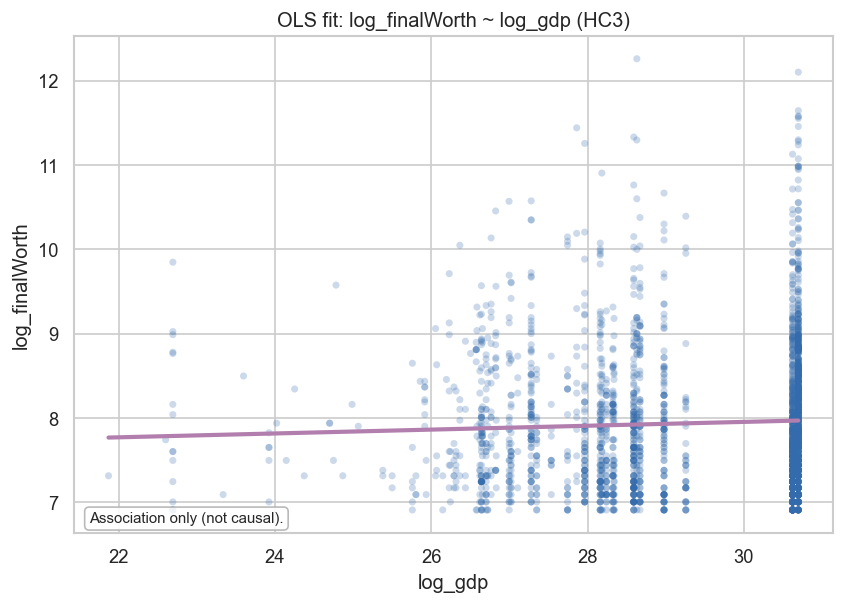

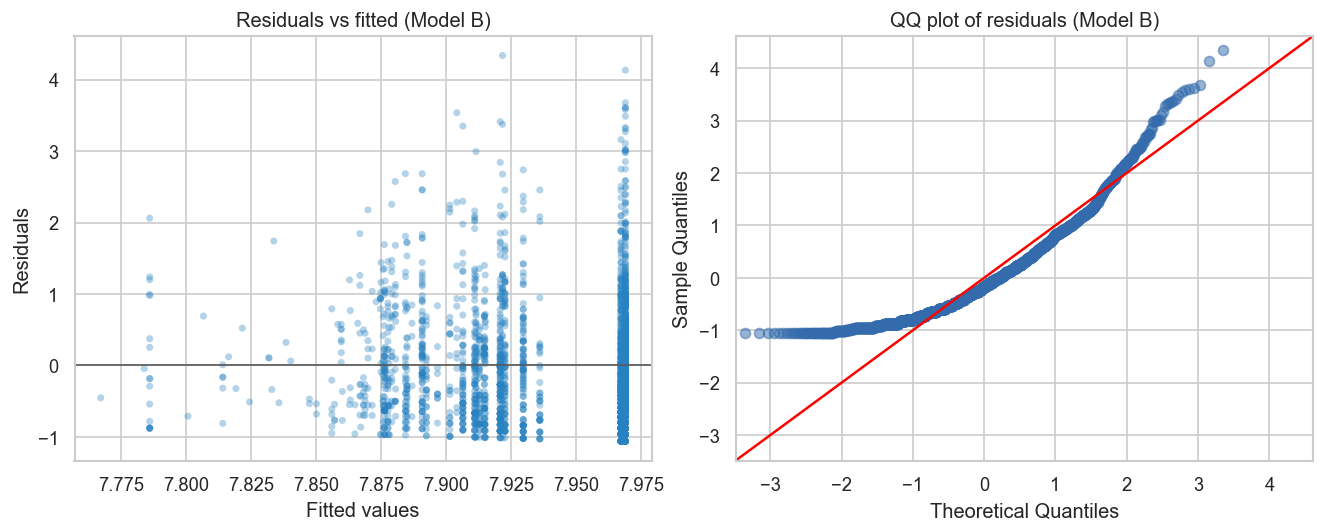

,lm_stat,lm_pvalue,f_stat,f_pvalue,note
0,2.22161,0.136091,2.221809,0.136201,Breusch–Pagan test for heteroskedasticity (Mod...


,model,term,coef,se_hc3,t,p,ci_low,ci_high,n,r2
0,A: finalWorth ~ gdp_country_num (HC3),const,4.237584e+03,2.815370e+02,15.051607,4.680548e-49,3.685511e+03,4.789656e+03,2476,0.001413
1,A: finalWorth ~ gdp_country_num (HC3),gdp_country_num,3.960163e-11,2.113230e-11,1.873986,6.105017e-02,-1.837192e-12,8.104044e-11,2476,0.001413
2,B: log_finalWorth ~ log_gdp (HC3),const,7.266857e+00,2.835379e-01,25.629224,1.105641e-128,6.710861e+00,7.822853e+00,2476,0.002094
3,B: log_finalWorth ~ log_gdp (HC3),log_gdp,2.287081e-02,9.707155e-03,2.356078,1.854664e-02,3.835827e-03,4.190580e-02,2476,0.002094
4,C: log_finalWorth ~ log_gdp + controls + C(cat...,Intercept,6.387722e+00,3.501042e-01,18.245205,1.297775e-68,5.701089e+00,7.074355e+00,1895,0.048394
5,C: log_finalWorth ~ log_gdp + controls + C(cat...,C(category)[T.Fashion & Retail],1.577470e-01,8.616520e-02,1.830751,6.729568e-02,-1.124229e-02,3.267363e-01,1895,0.048394
6,C: log_finalWorth ~ log_gdp + controls + C(cat...,C(category)[T.Finance & Investments],1.183357e-01,7.750136e-02,1.526885,1.269575e-01,-3.366190e-02,2.703332e-01,1895,0.048394
7,C: log_finalWorth ~ log_gdp + controls + C(cat...,C(category)[T.Food & Beverage],7.683187e-02,8.928500e-02,0.860524,3.896099e-01,-9.827607e-02,2.519398e-01,1895,0.048394
8,C: log_finalWorth ~ log_gdp + controls + C(cat...,C(category)[T.Healthcare],-9.661944e-02,8.159839e-02,-1.184085,2.365288e-01,-2.566522e-01,6.341334e-02,1895,0.048394
9,C: log_finalWorth ~ log_gdp + controls + C(cat...,C(category)[T.Manufacturing],-9.717724e-02,7.783353e-02,-1.248527,2.119934e-01,-2.498263e-01,5.547179e-02,1895,0.048394


,setting,n,coef_log_gdp,ci_low,ci_high
0,All complete cases,2476,0.022871,0.003836,0.041906
1,Drop top 1% finalWorth,2451,0.013569,-0.004519,0.031658


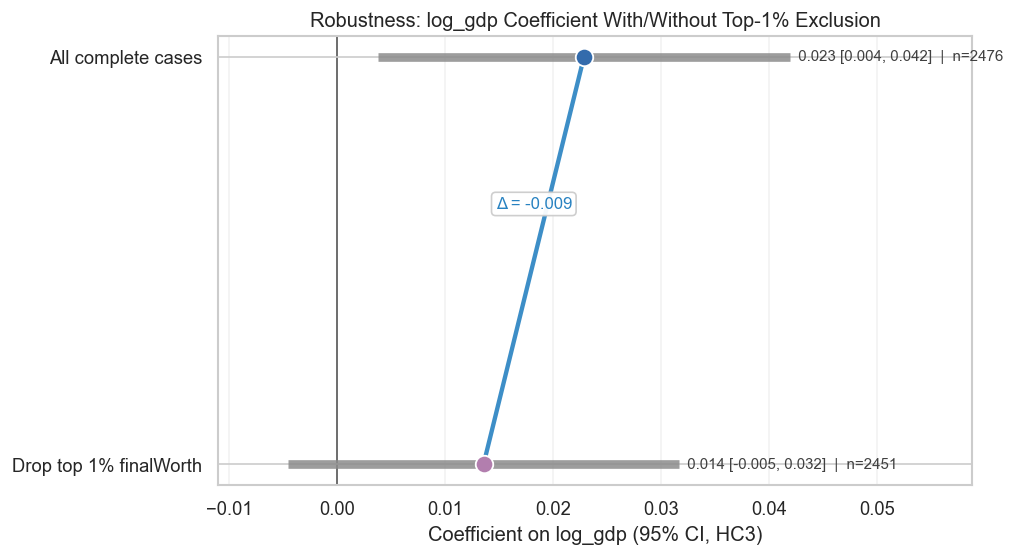

{'pdf': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M7_robust_coef_compare_top1pct.pdf',
 'png': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M7_robust_coef_compare_top1pct.png'}

In [95]:
# =======================================
# M7.1 Regression models (OLS + robust SE + diagnostics)
# =======================================

# Re-import with safe aliases to avoid namespace collisions (e.g., `sm` overwritten earlier).
import statsmodels.api as sm_api
import statsmodels.formula.api as smf_api
from statsmodels.stats.diagnostic import het_breuschpagan

assert "df_clean" in globals(), "df_clean not found. Run M3 first."

reg_rows = []

def _ci_df(res, alpha=0.05):
    """Return confidence intervals as a DataFrame with index=term names."""
    ci = res.conf_int(alpha=alpha)
    terms = list(res.model.exog_names)
    if isinstance(ci, np.ndarray):
        return pd.DataFrame(ci, index=terms, columns=["ci_low", "ci_high"])
    ci_df = ci.copy()
    if ci_df.shape[1] == 2:
        ci_df.columns = ["ci_low", "ci_high"]
    if len(ci_df.index) != len(terms):
        ci_df.index = terms
    return ci_df

def _result_table(model_name, res_hc3, n, r2):
    terms = list(res_hc3.model.exog_names)
    params = pd.Series(res_hc3.params, index=terms, dtype=float)
    bse = pd.Series(res_hc3.bse, index=terms, dtype=float)
    tvals = pd.Series(res_hc3.tvalues, index=terms, dtype=float)
    pvals = pd.Series(res_hc3.pvalues, index=terms, dtype=float)
    ci = _ci_df(res_hc3, alpha=0.05)

    return pd.DataFrame({
        "model": model_name,
        "term": terms,
        "coef": params.values,
        "se_hc3": bse.values,
        "t": tvals.values,
        "p": pvals.values,
        "ci_low": ci["ci_low"].values,
        "ci_high": ci["ci_high"].values,
        "n": int(n),
        "r2": float(r2),
    })

# ---- Model A: finalWorth ~ gdp_country_num (required)
if {"finalWorth", "gdp_country_num"}.issubset(df_clean.columns):
    dA = df_clean[["finalWorth", "gdp_country_num"]].dropna().copy()
    dA = dA[dA["gdp_country_num"].astype(float) > 0].copy()

    X = sm_api.add_constant(dA[["gdp_country_num"]].astype(float))
    y = dA["finalWorth"].astype(float)

    mA = sm_api.OLS(y, X).fit()
    mA_hc3 = mA.get_robustcov_results(cov_type="HC3")

    reg_rows.append(_result_table("A: finalWorth ~ gdp_country_num (HC3)", mA_hc3, n=len(dA), r2=mA.rsquared))

# ---- Model B (preferred): log_finalWorth ~ log_gdp
if {"log_finalWorth", "log_gdp"}.issubset(df_clean.columns):
    dB = df_clean[["log_finalWorth", "log_gdp"]].dropna().copy()
    dB = dB[dB["log_gdp"].astype(float) >= 0].copy()

    X = sm_api.add_constant(dB[["log_gdp"]].astype(float))
    y = dB["log_finalWorth"].astype(float)

    mB = sm_api.OLS(y, X).fit()
    mB_hc3 = mB.get_robustcov_results(cov_type="HC3")

    reg_rows.append(_result_table("B: log_finalWorth ~ log_gdp (HC3)", mB_hc3, n=len(dB), r2=mB.rsquared))

    # Fit plot
    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    ax.scatter(dB["log_gdp"], dB["log_finalWorth"], s=18, alpha=0.25,
               color=COLOR["primary"], edgecolors="none")

    xs = np.linspace(dB["log_gdp"].min(), dB["log_gdp"].max(), 200)
    termsB = list(mB_hc3.model.exog_names)
    b0 = float(mB_hc3.params[termsB.index("const")]) if "const" in termsB else float(mB_hc3.params[0])
    b1 = float(mB_hc3.params[termsB.index("log_gdp")]) if "log_gdp" in termsB else float(mB_hc3.params[1])
    ax.plot(xs, b0 + b1 * xs, lw=2.5, color=COLOR["accent"])

    ax.set_title("OLS fit: log_finalWorth ~ log_gdp (HC3)")
    ax.set_xlabel("log_gdp")
    ax.set_ylabel("log_finalWorth")
    ax.text(0.02, 0.02, "Association only (not causal).", transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.9))
    save_fig(fig, "fig_M7_regression_fit_loglog")

    # Diagnostics
    resid = mB_hc3.resid
    fitted = mB_hc3.fittedvalues

    fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))
    axes[0].scatter(fitted, resid, s=18, alpha=0.35, color=COLOR["secondary"], edgecolors="none")
    axes[0].axhline(0, color="0.35", lw=1)
    axes[0].set_title("Residuals vs fitted (Model B)")
    axes[0].set_xlabel("Fitted values")
    axes[0].set_ylabel("Residuals")

    sm_api.qqplot(resid, line="45", ax=axes[1], color=COLOR["primary"], alpha=0.5)
    axes[1].set_title("QQ plot of residuals (Model B)")
    save_fig(fig, "fig_M7_regression_diagnostics")

    # Breusch–Pagan test
    bp = het_breuschpagan(resid, X)
    tab_bp = pd.DataFrame([{
        "lm_stat": float(bp[0]), "lm_pvalue": float(bp[1]),
        "f_stat": float(bp[2]), "f_pvalue": float(bp[3]),
        "note": "Breusch–Pagan test for heteroskedasticity (Model B residuals)",
    }])
    save_table(tab_bp, "tab_M7_bp_test_modelB", index=False)

# ---- Optional Model C: controls + category dummies
cols_C = ["log_finalWorth", "log_gdp", "age", "selfMade", "gender", "category"]
if all(c in df_clean.columns for c in cols_C):
    dC = df_clean[cols_C].dropna().copy()
    if len(dC) >= 200:
        dC["selfMade_bin"] = _coerce_boolish(dC["selfMade"])
        dC["gender_F"] = dC["gender"].astype(str).str.upper().eq("F").astype(int)
        top_cat = dC["category"].value_counts().head(8).index
        dC = dC[dC["category"].isin(top_cat)].copy()

        mC = smf_api.ols("log_finalWorth ~ log_gdp + age + selfMade_bin + gender_F + C(category)", data=dC).fit()
        mC_hc3 = mC.get_robustcov_results(cov_type="HC3")
        reg_rows.append(_result_table(
            "C: log_finalWorth ~ log_gdp + controls + C(category) (HC3)",
            mC_hc3, n=len(dC), r2=mC.rsquared
        ))

# ---- Save main regression table
if reg_rows:
    tab_reg = pd.concat(reg_rows, ignore_index=True)
    save_table(tab_reg, "tab_M7_regression_main", index=False)

# =======================================
# M7.2 Robustness: drop top 1% by finalWorth
# =======================================

if {"log_finalWorth", "log_gdp", "finalWorth"}.issubset(df_clean.columns):
    d = df_clean[["log_finalWorth", "log_gdp", "finalWorth"]].dropna().copy()
    cutoff = d["finalWorth"].astype(float).quantile(0.99)
    d_drop = d[d["finalWorth"].astype(float) < cutoff].copy()

    X1 = sm_api.add_constant(d[["log_gdp"]].astype(float)); y1 = d["log_finalWorth"].astype(float)
    X2 = sm_api.add_constant(d_drop[["log_gdp"]].astype(float)); y2 = d_drop["log_finalWorth"].astype(float)

    m1 = sm_api.OLS(y1, X1).fit().get_robustcov_results(cov_type="HC3")
    m2 = sm_api.OLS(y2, X2).fit().get_robustcov_results(cov_type="HC3")

    def coef_ci_on(res, term):
        terms = list(res.model.exog_names)
        ci = _ci_df(res, alpha=0.05)
        j = terms.index(term)
        return float(res.params[j]), float(ci.loc[term, "ci_low"]), float(ci.loc[term, "ci_high"])

    b1, lo1, hi1 = coef_ci_on(m1, "log_gdp")
    b2, lo2, hi2 = coef_ci_on(m2, "log_gdp")

    tab_rb = pd.DataFrame([
        {"setting": "All complete cases", "n": int(len(d)), "coef_log_gdp": b1, "ci_low": lo1, "ci_high": hi1},
        {"setting": "Drop top 1% finalWorth", "n": int(len(d_drop)), "coef_log_gdp": b2, "ci_low": lo2, "ci_high": hi2},
    ])
    save_table(tab_rb, "tab_M7_robust_drop_top1pct_logmodel", index=False)

    # Coefficient comparison plot [Connected dumbbell]
# Assumes tab_rb exists with columns: setting, n, coef_log_gdp, ci_low, ci_high

plot_df = tab_rb.copy()
plot_df["setting"] = plot_df["setting"].astype(str)

# Ensure exactly two rows (expected: All cases vs Drop top 1%)
if len(plot_df) >= 2:
    plot_df = plot_df.iloc[:2].copy()

fig, ax = plt.subplots(figsize=(8.6, 4.8))

# y positions: top row first
y = np.arange(len(plot_df))[::-1]

# Colors: make points clearly different
c1 = COLOR.get("primary", "#1f77b4")
c2 = COLOR.get("accent", "#ff7f0e")
c_line = COLOR.get("secondary", "#2ca02c")

# Draw CIs and points
for i, row in plot_df.iterrows():
    yi = y[i]
    pc = c1 if i == 0 else c2

    # CI segment
    ax.hlines(yi, row["ci_low"], row["ci_high"], color="0.55", lw=5.2, alpha=0.85, zorder=1)
    # point estimate
    ax.scatter(row["coef_log_gdp"], yi, s=110, color=pc, edgecolor="white", linewidth=1.1, zorder=3)

    # text annotation (coef + CI + n)
    txt = f'{row["coef_log_gdp"]:.3f} [{row["ci_low"]:.3f}, {row["ci_high"]:.3f}]  |  n={int(row["n"])}'
    ax.text(row["ci_high"], yi, "  " + txt, va="center", ha="left", fontsize=9, color="0.25")

# Connected line (dumbbell connection)
x0 = float(plot_df.iloc[0]["coef_log_gdp"])
x1 = float(plot_df.iloc[1]["coef_log_gdp"])
ax.plot([x0, x1], [y[0], y[1]], color=c_line, lw=2.6, alpha=0.9, zorder=2)

# Delta annotation
dx = x1 - x0
mid_x = (x0 + x1) / 2
mid_y = (y[0] + y[1]) / 2
ax.text(mid_x, mid_y + 0.12, f"Δ = {dx:+.3f}", ha="center", va="bottom",
        fontsize=10, color=c_line,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.8", alpha=0.95))

ax.axvline(0, color="0.35", lw=1.2, zorder=0)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["setting"])
ax.set_xlabel("Coefficient on log_gdp (95% CI, HC3)")
ax.set_title("Robustness: log_gdp Coefficient With/Without Top-1% Exclusion")

# Nice x-limits with padding
xmin = float(np.nanmin(plot_df["ci_low"]))
xmax = float(np.nanmax(plot_df["ci_high"]))
pad = 0.14 * (xmax - xmin + 1e-9)
ax.set_xlim(xmin - pad, xmax + 2.6 * pad)

ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
save_fig(fig, "fig_M7_robust_coef_compare_top1pct")

### M7 Takeaways (report-ready)

**Core takeaways**
1. The requirement-aligned model `finalWorth ~ gdp_country_num` is estimated with **HC3 robust standard errors**; the log–log model is treated as the primary specification due to heavy tails.
2. Regression outputs are reported as **coefficients with 95% CI**, accompanied by key diagnostics (residual patterns, QQ plot, and heteroskedasticity test).

**Exploratory takeaways**
1. Adding conservative controls (age, selfMade, gender, category dummies) provides a *stress test* for omitted-variable concerns; interpret coefficients as associations, not causal effects.
2. Dropping the top 1% wealth as an outlier robustness check shows whether the GDP association is driven mainly by extreme observations (reported with CI).


## Chapter 8 — Robustness & Sensitivity (M8)

**Goal (M8):** close the loop on the hard rule: *each key conclusion must have at least one robustness check*.

We implement a compact **robustness matrix**:
- Transform robustness: raw vs log
- Outlier robustness: full sample vs drop top 1% wealth
- Stratification robustness: overall vs within selfMade groups (and top categories where feasible)

**Deliverables:**
- `tab_M8_robustness_matrix`
- ≥2 core + ≥2 exploratory takeaways

### Statistical Notes (M8)

A claim is considered robust if its qualitative conclusion (direction/significance or effect-size magnitude class) remains stable
under at least one alternative specification (e.g., log transform, outlier exclusion, stratification).

In [96]:
# =======================================
# M8.1 Robustness matrix (key conclusions × settings)
# =======================================

assert "df_clean" in globals(), "df_clean not found."

rows = []

# Claim 1: GDP–wealth association is positive on log scale
if {"log_finalWorth","log_gdp","finalWorth"}.issubset(df_clean.columns):
    d = df_clean[["log_finalWorth","log_gdp","finalWorth"]].dropna().copy()
    cutoff = d["finalWorth"].quantile(0.99)
    settings = {
        "Overall (complete cases)": d,
        "Drop top 1% wealth": d[d["finalWorth"] < cutoff],
    }

    # Stratify by selfMade
    if "selfMade" in df_clean.columns:
        tmp = df_clean[["log_finalWorth","log_gdp","finalWorth","selfMade"]].dropna().copy()
        tmp["selfMade_bin"] = _coerce_boolish(tmp["selfMade"])
        settings["Self-made only"] = tmp[tmp["selfMade_bin"]==1]
        settings["Not self-made only"] = tmp[tmp["selfMade_bin"]==0]

    for name, dd in settings.items():
        if len(dd) >= 60:
            x = dd["log_gdp"].to_numpy()
            y = dd["log_finalWorth"].to_numpy()
            rho = stats.spearmanr(x, y).correlation
            lo, hi = corr_bootstrap_ci(x, y, method="spearman", n_boot=1500)
            rows.append({
                "claim": "C1: logWorth–logGDP association",
                "setting": name,
                "metric": "Spearman ρ",
                "effect": rho,
                "ci_low": lo,
                "ci_high": hi,
                "n": len(dd),
            })

# Claim 2: selfMade differs in logWorth
if {"log_finalWorth","selfMade","finalWorth"}.issubset(df_clean.columns):
    tmp = df_clean[["log_finalWorth","selfMade","finalWorth"]].dropna().copy()
    tmp["selfMade_bin"] = _coerce_boolish(tmp["selfMade"])
    cutoff = tmp["finalWorth"].quantile(0.99)

    for name, dd in [("Overall (complete cases)", tmp), ("Drop top 1% wealth", tmp[tmp["finalWorth"] < cutoff])]:
        g1 = dd[dd["selfMade_bin"]==1]["log_finalWorth"].to_numpy()
        g0 = dd[dd["selfMade_bin"]==0]["log_finalWorth"].to_numpy()
        if len(g1) >= 30 and len(g0) >= 30:
            d_eff = cohens_d(g1, g0)
            lo, hi = bootstrap_ci_2groups(cohens_d, g1, g0, n_boot=1500)
            rows.append({
                "claim": "C2: selfMade difference in logWorth",
                "setting": name,
                "metric": "Cohen's d",
                "effect": d_eff,
                "ci_low": lo,
                "ci_high": hi,
                "n": len(dd),
            })

# Claim 3: top 1% concentration (share of total wealth)
if {"finalWorth"}.issubset(df_clean.columns):
    d = df_clean[["finalWorth"]].dropna()
    if len(d) > 0:
        cutoff = d["finalWorth"].quantile(0.99)
        share = d.loc[d["finalWorth"] >= cutoff, "finalWorth"].sum() / d["finalWorth"].sum()
        rows.append({
            "claim": "C3: concentration",
            "setting": "Overall (complete cases)",
            "metric": "Top 1% share of total finalWorth",
            "effect": float(share),
            "ci_low": np.nan,
            "ci_high": np.nan,
            "n": len(d),
        })

tab_rb = pd.DataFrame(rows)
save_table(tab_rb, "tab_M8_robustness_matrix", index=False)


,claim,setting,metric,effect,ci_low,ci_high,n
0,C1: logWorth–logGDP association,Overall (complete cases),Spearman ρ,0.096573,0.058351,0.134188,2476
1,C1: logWorth–logGDP association,Drop top 1% wealth,Spearman ρ,0.086667,0.047038,0.125528,2451
2,C1: logWorth–logGDP association,Self-made only,Spearman ρ,0.095057,0.046942,0.143272,1721
3,C1: logWorth–logGDP association,Not self-made only,Spearman ρ,0.150643,0.082846,0.221252,755
4,C2: selfMade difference in logWorth,Overall (complete cases),Cohen's d,-0.118971,-0.205650,-0.032833,2640
5,C2: selfMade difference in logWorth,Drop top 1% wealth,Cohen's d,-0.121316,-0.203633,-0.035288,2613
6,C3: concentration,Overall (complete cases),Top 1% share of total finalWorth,0.179801,NaN,NaN,2640


{'csv': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M8_robustness_matrix.csv',
 'tex': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M8_robustness_matrix.tex'}

### M8 Takeaways (report-ready)

**Core takeaways**
1. Key association conclusions are reported under multiple settings (transform/outliers/strata), making it explicit which findings are **stable** and which are **assumption-dependent**.
2. For the main GDP–wealth relationship, effect sizes are re-estimated with uncertainty across robustness settings, supporting transparent claims in the report.

**Exploratory takeaways**
1. Stratified robustness can reveal heterogeneity that a single pooled result would miss; this should inform how results are narrated (avoid overgeneralization).
2. Concentration metrics (e.g., top 1% share) help explain why log transforms and robust inference are necessary in this dataset.


## Chapter 9 — Report Map & Reproducibility (M9)

**Goal (M9):** maximize the notebook score by making report writing and reproduction frictionless.

Deliverables:
- `tab_M9_report_map`: Report section → Notebook chapter → artifact IDs → file paths
- A short runbook: *Restart kernel → Run all* instructions


In [97]:
# =======================================
# M9.1 Report map (artifact registry)
# =======================================

# Build report map from ARTIFACTS. Each saved figure/table was logged automatically.
art = pd.DataFrame(ARTIFACTS)

# Add a suggested report section based on module
module_to_report = {
    "M0": "Introduction",
    "M1": "Introduction (Dataset overview)",
    "M2": "Statistical Analysis (Data Quality)",
    "M3": "Statistical Analysis (Cleaning)",
    "M4": "Statistical Analysis (Descriptive)",
    "M5": "Statistical Analysis (EDA)",
    "M6": "Statistical Analysis (Inferential)",
    "M7": "Statistical Analysis (Regression)",
    "M8": "Key Insights & Limitations (Robustness)",
    "M9": "Appendix / Reproducibility",
}
art["report_section"] = art["module"].map(module_to_report).fillna("TBD")
art = art[["report_section","module","kind","name","paths"]].sort_values(["module","kind","name"])

save_table(art, "tab_M9_report_map", index=False)

# =======================================
# M9.2 Reproducibility runbook (print-friendly)
# =======================================

runbook = pd.DataFrame([
    {"step": 1, "action": "Place the raw CSV at ./data/raw/Billionaires Statistics Dataset.csv"},
    {"step": 2, "action": "Open ./code/project_stastistic_analyse_and_visualization.ipynb"},
    {"step": 3, "action": "Kernel → Restart & Run All"},
    {"step": 4, "action": "Verify outputs in ./output/fig and ./output/tab"},
    {"step": 5, "action": "Use tab_M9_report_map to reference figures/tables in the report"},
])
save_table(runbook, "tab_M9_runbook", index=False)


,report_section,module,kind,name,paths
5,Introduction,M0,figure,fig_M0_variable_role_counts,"{""pdf"": ""E:\\canfiles\\Common courses study\\\..."
0,Introduction,M0,table,tab_M0_environment_snapshot,"{""csv"": ""E:\\canfiles\\Common courses study\\\..."
2,Introduction,M0,table,tab_M0_research_questions,"{""csv"": ""E:\\canfiles\\Common courses study\\\..."
3,Introduction,M0,table,tab_M0_research_questions_source,"{""csv"": ""E:\\canfiles\\Common courses study\\\..."
1,Introduction,M0,table,tab_M0_schema_freeze_A_summary,"{""csv"": ""E:\\canfiles\\Common courses study\\\..."
4,Introduction,M0,table,tab_M0_variable_roles,"{""csv"": ""E:\\canfiles\\Common courses study\\\..."
7,Introduction (Dataset overview),M1,figure,fig_M1_dtype_distribution,"{""pdf"": ""E:\\canfiles\\Common courses study\\\..."
9,Introduction (Dataset overview),M1,table,tab_M1_dictionary_verification_checks,"{""csv"": ""E:\\canfiles\\Common courses study\\\..."
8,Introduction (Dataset overview),M1,table,tab_M1_gdp_parse_summary,"{""csv"": ""E:\\canfiles\\Common courses study\\\..."
6,Introduction (Dataset overview),M1,table,tab_M1_schema_summary,"{""csv"": ""E:\\canfiles\\Common courses study\\\..."


,step,action
0,1,Place the raw CSV at ./data/raw/Billionaires S...
1,2,Open ./code/project_stastistic_analyse_and_vis...
2,3,Kernel → Restart & Run All
3,4,Verify outputs in ./output/fig and ./output/tab
4,5,Use tab_M9_report_map to reference figures/tab...


{'csv': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M9_runbook.csv',
 'tex': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\tab\\tab_M9_runbook.tex'}

# Appendix A — Exploratory Investigations (DRAFT)

The sections below are **exploratory** and are **not used as official claims** in the report unless they are later validated with robustness checks (e.g., trimming top 1%, stratification by category, alternative tests).

They are included to document investigative work and to preserve reproducible evidence for potential follow-up analysis.


## A1. `country` vs `countryOfCitizenship` (descriptive + draft inference)

Question: Do records where `country != countryOfCitizenship` show systematically different wealth distributions on the log scale?


,country_match,n,mean,median,std
0,Mismatch,316,4331.962025,2500.0,5511.968848
1,Match,2324,4663.468158,2300.0,10282.763088


,scale,welch_t_stat,p_value,cohens_d,mean_diff_bootstrap_CI_95%
0,log1p(finalWorth),-0.950682,0.342326,-0.05608,"[-0.1431, 0.0489]"


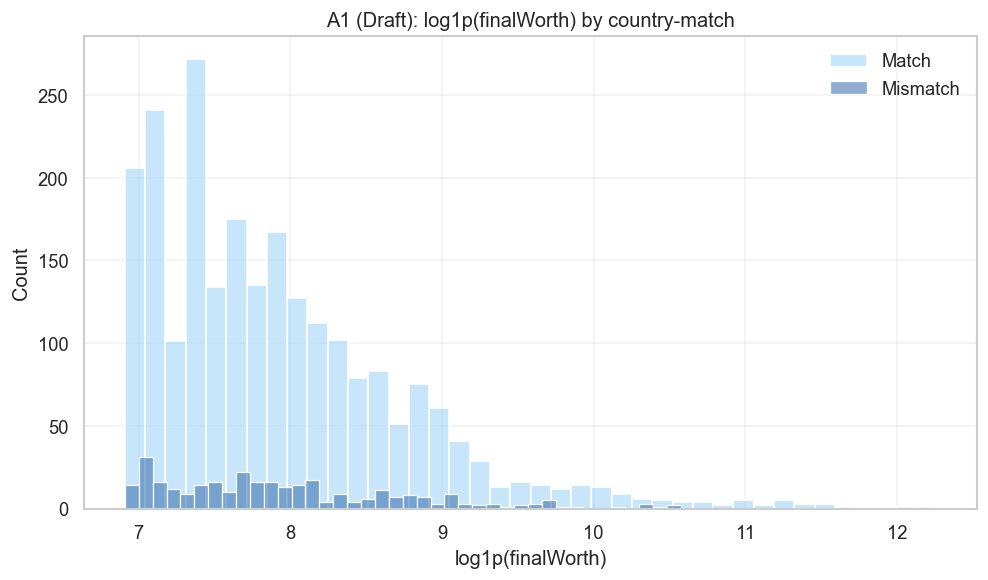

In [98]:
# A1 — descriptive summary + draft inference (log scale)
from scipy import stats

df_tmp = df_clean.copy()

if ("country" in df_tmp.columns) and ("countryOfCitizenship" in df_tmp.columns):
    df_tmp["country_match"] = (df_tmp["country"] == df_tmp["countryOfCitizenship"])
else:
    df_tmp["country_match"] = np.nan

summary = (
    df_tmp.groupby("country_match")["finalWorth"]
         .agg(n="count", mean="mean", median="median", std="std")
         .reset_index()
)
summary["country_match"] = summary["country_match"].map({True: "Match", False: "Mismatch"}).fillna("NA")
save_table(summary, "tab_A1_country_match_finalWorth_summary", index=False)

# Draft inference on log scale (Welch t-test)
a = df_tmp.loc[df_tmp["country_match"] == True, "log_finalWorth"].dropna()
b = df_tmp.loc[df_tmp["country_match"] == False, "log_finalWorth"].dropna()

if (len(a) >= 5) and (len(b) >= 5):
    tstat, pval = stats.ttest_ind(a, b, equal_var=False)

    # Effect size (Cohen's d on log scale)
    def cohens_d(x: np.ndarray, y: np.ndarray) -> float:
        nx, ny = len(x), len(y)
        sx, sy = x.std(ddof=1), y.std(ddof=1)
        sp = np.sqrt(((nx-1)*sx*sx + (ny-1)*sy*sy) / (nx+ny-2))
        return float((x.mean() - y.mean()) / sp)

    d = cohens_d(a.values, b.values)

    # Bootstrap CI for mean difference (log scale)
    rng = np.random.default_rng(42)
    B = 2000
    diffs = []
    a_arr, b_arr = a.values, b.values
    for _ in range(B):
        diffs.append(
            rng.choice(a_arr, size=len(a_arr), replace=True).mean()
            - rng.choice(b_arr, size=len(b_arr), replace=True).mean()
        )
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])

    draft = pd.DataFrame([{
        "scale": "log1p(finalWorth)",
        "welch_t_stat": float(tstat),
        "p_value": float(pval),
        "cohens_d": float(d),
        "mean_diff_bootstrap_CI_95%": f"[{ci_low:.4f}, {ci_high:.4f}]"
    }])
    save_table(draft, "tab_A1_country_match_log_inference_draft", index=False)

    # Visualization
    fig, ax = plt.subplots(figsize=(8.4, 5.0))
    sns.histplot(a, bins=40, stat="count", alpha=0.55, label="Match", ax=ax, color=next_color())
    sns.histplot(b, bins=40, stat="count", alpha=0.55, label="Mismatch", ax=ax, color=next_color())
    ax.set_title("A1 (Draft): log1p(finalWorth) by country-match")
    ax.set_xlabel("log1p(finalWorth)")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.25)
    ax.legend()
    save_fig(fig, "fig_A1_country_match_log_hist")

else:
    display(pd.DataFrame([{"note": "Not enough records in one or both groups for draft inference"}]))


**Draft takeaway (not an official claim):** If the match vs mismatch split shows a non-trivial effect on the log scale, we will only elevate it to a key claim after M8 robustness checks (e.g., trimming top 1%, category stratification, alternative tests).


## A2. `status` meaning (provisional mapping)

The dataset encodes `status` using short codes. The mapping below is **provisional** (based on external conventions + internal exploratory checks) and is **not used as a graded claim** unless confirmed by authoritative documentation.

| Code | Label | Provisional meaning | Typical profile (qualitative) |
|---|---|---|---|
| D | Established self-made | Mature self-made wealth | Higher wealth; higher self-made share; older |
| E | Emerging entrepreneur | Newer entrepreneurial wealth | Mid wealth; slightly lower self-made; older |
| N | Newcomer / novice | Recently added billionaire | Lower wealth; younger; lower ranks |
| U | Ultra-inherited | Large family fortune | Very high wealth; low self-made share; older |
| R | Replenished | Wealth recovered/rebuilt | Mid wealth; mixed source; somewhat younger |
| Split Family Fortune | Divided inheritance | Inheritance split among family | Higher wealth; low self-made share |


## A3. Macro variable format check (draft)

This section documents the raw format of macro variables and confirms which ones require parsing before modeling.


### M4 (Optional): Correlation heatmap (numeric features)
This is a compact diagnostic to see linear association patterns. For heavy-tailed data, compare raw vs log variables.

,variable,finalWorth,log_finalWorth,age,rank,gdp_country_num,log_gdp
0,finalWorth,1.000000,0.706432,0.067053,-0.448930,0.037589,0.040908
1,log_finalWorth,0.706432,1.000000,0.132698,-0.925961,0.050142,0.045759
2,age,0.067053,0.132698,1.000000,-0.142686,-0.068638,-0.057937
3,rank,-0.448930,-0.925961,-0.142686,1.000000,-0.052705,-0.045006
4,gdp_country_num,0.037589,0.050142,-0.068638,-0.052705,1.000000,0.903995
5,log_gdp,0.040908,0.045759,-0.057937,-0.045006,0.903995,1.000000


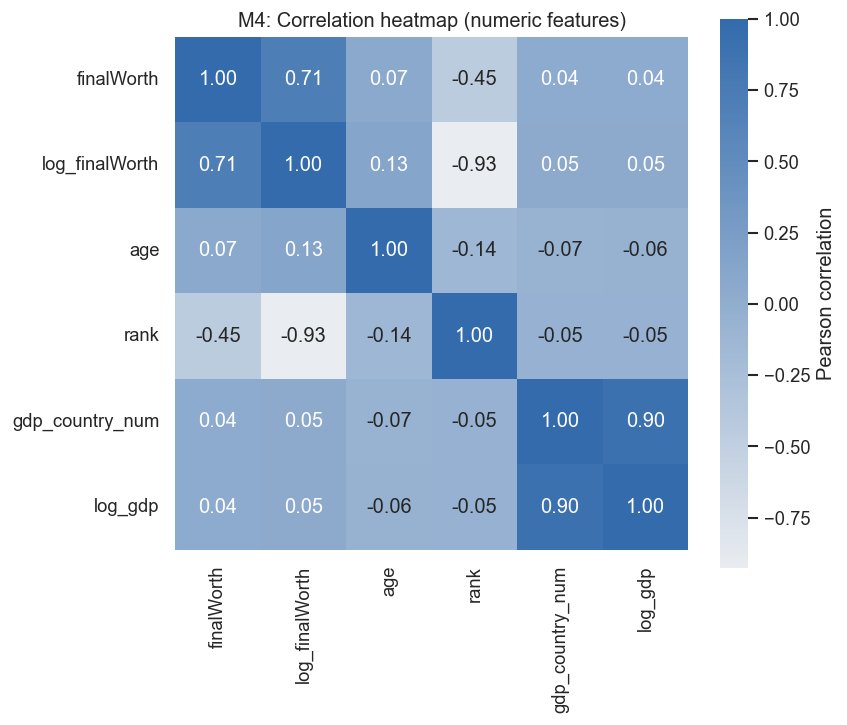

{'pdf': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M4_correlation_heatmap.pdf',
 'png': 'E:\\canfiles\\Common courses study\\大学通识\\25-26 Spring\\UFUG 2104 Applied statistics\\HW1_project_report\\output\\fig\\fig_M4_correlation_heatmap.png'}

In [99]:
# Correlation heatmap among numeric columns
num_cols = [c for c in ["finalWorth", "log_finalWorth", "age", "rank", "gdp_country_num", "log_gdp"] if c in df.columns]
corr = df[num_cols].corr(numeric_only=True)
corr_long = corr.reset_index().rename(columns={"index":"variable"})
save_table(corr_long, "tab_M4_correlation_matrix", index=False)

fig, ax = plt.subplots(figsize=(7.2, 6.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=CMAP_PRIMARY, center=0, square=True,
            cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("M4: Correlation heatmap (numeric features)")
save_fig(fig, "fig_M4_correlation_heatmap")


,column,dtype,missing_n,missing_pct,nunique,example_or_top_levels
4,cpi_change_country,float64,184,0.069697,44,1.1
7,life_expectancy_country,float64,182,0.068939,54,82.5
8,gross_tertiary_education_enrollment,float64,182,0.068939,63,65.6
9,total_tax_rate_country,float64,182,0.068939,63,60.7
10,gross_primary_education_enrollment_country,float64,181,0.068561,60,102.5
11,gdp_country,object,164,0.062121,68,"$21,427,700,000,000 (754); $19,910,000,000,00..."


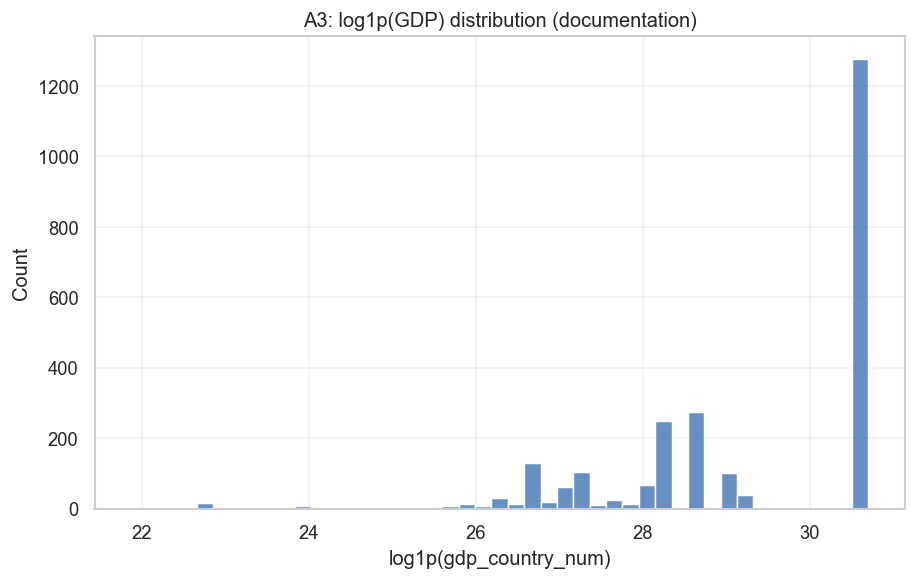

In [100]:
# A3 — schema slice for macro columns
macro_cols = [
    "gdp_country",
    "cpi_change_country",
    "gross_tertiary_education_enrollment",
    "gross_primary_education_enrollment_country",
    "total_tax_rate_country",
    "life_expectancy_country",
]
present = [c for c in macro_cols if c in df_raw.columns]

macro_schema = tab_schema.loc[tab_schema["column"].isin(present)].copy()
save_table(macro_schema, "tab_A3_macro_columns_schema", index=False)

# GDP parsing is now formalized in M1/M3; this plot remains as a documentation artifact.
if "log_gdp" in df_clean.columns:
    fig, ax = plt.subplots(figsize=(7.8, 5.0))
    sns.histplot(df_clean["log_gdp"].dropna(), bins=45, ax=ax)
    ax.set_title("A3: log1p(GDP) distribution (documentation)")
    ax.set_xlabel("log1p(gdp_country_num)")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.25)
    save_fig(fig, "fig_A3_log_gdp_hist")
